# Module 2 - Threat Modeling AI Systems

---

<details>

<summary><b>Module Overview — Click to Expand</b></summary>

<br>

AI systems introduce security risks across data collection, model training, inference, deployment, and the supporting infrastructure around them. Identifying these risks before an attack occurs is an important part of building secure AI systems.

This module introduces **threat modeling for AI systems**.

Threat modeling provides a structured way to understand a system, identify what could go wrong, evaluate the importance of identified threats, and determine how those threats should be addressed.

You will learn how to use three approaches:

- **STRIDE** to identify security threats
- **DREAD** to help evaluate and prioritize identified risks
- **Failure Modes and Effects Analysis (FMEA)** to examine potential failures and their consequences

You will also examine the AI/ML lifecycle to understand how attack surfaces change across data management, training, inference, and deployment.

Throughout the module, short demonstrations will show how these techniques can be applied to simplified AI security scenarios.

At the end of the module, you will create a threat model for an **AI-based phishing detection system**, identify threats across its components, evaluate their risks, and recommend appropriate mitigations.

</details>

<details>

<summary><b>Learning Objectives — Click to Expand</b></summary>

<br>
In Module 1, you explored the foundational principles of AI security, including how artificial intelligence is used in cybersecurity and the risks these systems introduce. Now, you will take the next step by learning how to proactively identify, assess, and mitigate those risks through structured threat modeling.

As AI becomes increasingly embedded in cyber operations, powering tools for malware detection, phishing analysis, and anomaly detection,it also introduces new attack surfaces. Adversaries can exploit vulnerabilities in data, models, pipelines, and deployment environments. Without a systematic approach to risk identification, these weaknesses can undermine even the most advanced security technologies.

In this module, you will learn how to apply industry-recognized methodologies to secure AI systems. You will use STRIDE to identify threats, DREAD to prioritize risks, and Failure Modes and Effects Analysis (FMEA) to evaluate potential failures and their impact. Through a hands-on case study involving an AI-based phishing detection system, you will gain practical experience developing and analyzing a real-world threat model.

By the end of this module, you should be able to:

1. **Explain the purpose of threat modeling** and how it supports proactive AI security.

2. **Identify important assets, components, data flows, and trust boundaries** within an AI system.

3. **Describe the AI/ML pipeline attack surface** and recognize how threats can occur at different lifecycle stages.

4. **Apply STRIDE** to identify potential threats against AI system components.

5. **Use DREAD-style risk scoring** to compare and prioritize identified threats.

6. **Apply Failure Modes and Effects Analysis (FMEA)** to identify AI system failures and evaluate their potential effects.

7. **Explain the differences between STRIDE, DREAD, and FMEA** and how they can complement one another.

8. **Recommend security controls** based on identified AI threats and risks.

9. **Develop a basic threat model for an AI system** using system components, attack surfaces, threats, risk assessments, and mitigations.

</details>

---

<details>

<summary><b>Section 1 — Foundations of Threat Modeling — Click to Expand</b></summary>

<br>

Threat modeling is a **proactive security process** used to identify potential security problems before attackers exploit them.

Instead of waiting for a vulnerability or breach to occur, defenders examine how a system works and ask how an attacker might attempt to compromise it.

---

<details>

<summary><b>1.1 — What Is Threat Modeling?</b></summary>

<br>

Threat modeling is the process of examining a system to identify potential threats, understand how those threats could affect the system, and determine how they should be addressed.

At a basic level, threat modeling attempts to answer four questions:

1. **What are we building?**
2. **What can go wrong?**
3. **What should we do about it?**
4. **Did we address the important risks?**

Before defenders can identify threats, they must first understand the system.

This normally involves identifying:

- Important assets
- System components
- Users and external actors
- Data flows
- Entry points
- Trust boundaries
- Dependencies

Once the system is understood, defenders can begin considering how an attacker might interact with those components.

</details>

---

<details>

<summary><b>1.2 — Why Threat Modeling Is Proactive</b></summary>

<br>

Many security activities occur after a system has already been developed or deployed.

Threat modeling attempts to identify security concerns **earlier**.

For example, imagine an organization is developing an AI phishing detector.

Instead of waiting until deployment to discover that attackers can submit unlimited queries to the model, the development team could identify that interface during threat modeling.

They could then ask:

- Who can access the model?
- What information does it return?
- Could an attacker abuse repeated queries?
- Could malicious inputs manipulate predictions?
- What happens if the model becomes unavailable?

Discovering these concerns early allows security controls to be considered during system design.

</details>

---

<details>

<summary><b>1.3 — Threat Modeling AI Systems</b></summary>

<br>

Traditional applications already contain many components that attackers can target.

AI systems introduce additional components.

An AI application may contain:

- Training datasets
- Data pipelines
- Training infrastructure
- Model weights
- Model APIs
- User inputs
- Model outputs
- Monitoring systems
- External models
- Third-party libraries

This means threat modeling an AI application requires examining both **traditional cybersecurity threats** and **AI-specific threats**.

For example, defenders may need to consider traditional problems such as unauthorized access while also considering AI-specific problems such as data poisoning or adversarial inputs.

</details>

</details>

In [ ]:
# @title ▶ Section 1 Checkpoint — Foundations of Threat Modeling { display-mode: "form" }

questions = [
    {
        "question": "1. What is the primary purpose of threat modeling?",
        "options": [
            "A. Respond to attacks after they occur",
            "B. Proactively identify and address potential threats",
            "C. Increase model accuracy",
            "D. Replace vulnerability scanning"
        ],
        "answer": "B"
    },
    {
        "question": "2. Which question should be answered during threat modeling?",
        "options": [
            "A. What are we building?",
            "B. What can go wrong?",
            "C. What should we do about it?",
            "D. All of the above"
        ],
        "answer": "D"
    },
    {
        "question": "3. Why can AI systems require additional threat modeling considerations?",
        "options": [
            "A. They introduce assets such as datasets and models",
            "B. AI systems cannot be attacked",
            "C. Traditional security no longer applies",
            "D. AI systems contain no software"
        ],
        "answer": "A"
    }
]

score = 0

for q in questions:
    print("\n" + q["question"])
    for option in q["options"]:
        print(option)

    response = input("Your answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print(f"\nFinal Score: {score}/{len(questions)}")

---

<details>

<summary><b>Section 2 — Understanding the AI/ML Attack Surface — Click to Expand</b></summary>

<br>

An **attack surface** includes the components, interfaces, processes, and resources that an attacker could potentially target.

AI systems have attack surfaces that extend across the entire machine learning lifecycle.

Understanding this lifecycle is one of the first steps in creating an AI threat model.

---

<details>

<summary><b>2.1 — Data Management</b></summary>

<br>

The data management stage involves collecting, storing, cleaning, labeling, and preparing information for model training.

Important assets may include:

- Raw datasets
- Labels
- Metadata
- Data storage
- Data-processing scripts
- Data sources

Potential threats include:

- Data poisoning
- Label manipulation
- Unauthorized dataset modification
- Sensitive information exposure
- Compromised data sources

Security at this stage focuses heavily on **data integrity, confidentiality, provenance, and access control**.

</details>

---

<details>

<summary><b>2.2 — Model Training and Tuning</b></summary>

<br>

During training, algorithms learn patterns from prepared datasets.

Important assets include:

- Training code
- Model parameters
- Hyperparameters
- Model checkpoints
- Training infrastructure
- Validation datasets

Attackers may attempt to manipulate training scripts, alter model parameters, insert backdoors, steal model information, or compromise training infrastructure.

A compromised training process can produce a compromised model even if the deployment environment itself is secure.

</details>

---

<details>

<summary><b>2.3 — Inference and Serving</b></summary>

<br>

Inference occurs when a trained model receives new information and generates a prediction or output.

Important assets include:

- Model APIs
- User inputs
- Predictions
- Confidence scores
- Model weights
- Authentication mechanisms

Potential attacks include:

- Adversarial inputs
- Model extraction
- Membership inference
- API abuse
- Resource exhaustion

This stage is particularly important because deployed models may be exposed directly or indirectly to untrusted users.

</details>

---

<details>

<summary><b>2.4 — Deployment and Monitoring</b></summary>

<br>

Once deployed, an AI system must continue to operate securely.

Important components include:

- Cloud infrastructure
- Containers
- APIs
- Logging systems
- Monitoring tools
- Model repositories
- Update mechanisms

Threats at this stage may include unauthorized access, insecure configurations, compromised dependencies, model replacement, or insufficient monitoring.

Security therefore continues after model training and deployment.

</details>

</details>

In [ ]:
# @title ▶ Explore an AI Attack Surface { display-mode: "form" }

pipeline = {
    "Data Management": [
        "Data Poisoning",
        "Label Manipulation",
        "Sensitive Data Exposure"
    ],

    "Model Training": [
        "Training Code Tampering",
        "Backdoor Injection",
        "Model Theft"
    ],

    "Inference": [
        "Adversarial Inputs",
        "Model Extraction",
        "API Abuse"
    ],

    "Deployment": [
        "Unauthorized Access",
        "Dependency Compromise",
        "Model Replacement"
    ]
}

print("=== AI/ML Attack Surface ===")

for stage, threats in pipeline.items():

    print(f"\n{stage}")

    for threat in threats:
        print("  -", threat)

<details>

<summary><b>Hands-On Learning Context — Click to Expand</b></summary>

<br>

This activity demonstrates one of the first steps in AI threat modeling: **mapping potential threats to the components they can affect**.

Notice that there is no single location where every AI attack occurs.

For example:

**Data poisoning** primarily targets information used during training.

**Adversarial inputs** primarily target the model during inference.

**Dependency compromise** may affect the environment used to develop or deploy the AI application.

Threat modeling therefore requires defenders to examine the **entire AI lifecycle**.

A useful question throughout this module is:

> **Where could an attacker interact with or influence this system?**

Identifying those locations helps defenders build the system's attack surface before applying structured threat modeling techniques.

</details>

In [ ]:
# @title ▶ Section 2 Checkpoint — Understanding the AI/ML Attack Surface { display-mode: "form" }

questions = [
    {
        "question": "1. Which stage of the AI/ML lifecycle is most directly affected by data poisoning?",
        "options": [
            "A. Data Management",
            "B. Inference",
            "C. User Authentication",
            "D. Deployment Monitoring"
        ],
        "answer": "A"
    },
    {
        "question": "2. Which threat is most closely associated with the inference and serving stage?",
        "options": [
            "A. Training label manipulation",
            "B. Adversarial inputs",
            "C. Corrupting a training dataset",
            "D. Changing training hyperparameters"
        ],
        "answer": "B"
    },
    {
        "question": "3. Why should defenders examine the entire AI/ML lifecycle when identifying the attack surface?",
        "options": [
            "A. Attacks can target components at multiple stages of the lifecycle",
            "B. All AI attacks occur during training",
            "C. Only deployed models require security",
            "D. Traditional security threats do not affect AI systems"
        ],
        "answer": "A"
    },
    {
        "question": "4. Which of the following is an important asset during model training?",
        "options": [
            "A. Model parameters",
            "B. Training code",
            "C. Training infrastructure",
            "D. All of the above"
        ],
        "answer": "D"
    }
]

score = 0

for q in questions:
    print("\n" + q["question"])
    for option in q["options"]:
        print(option)

    response = input("Your answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print(f"\nFinal Score: {score}/{len(questions)}")

---

<details>

<summary><b>Section 3 — STRIDE for AI Systems — Click to Expand</b></summary>

<br>

After understanding the system and its attack surface, defenders need a structured method for identifying threats.

One commonly used approach is **STRIDE**.

STRIDE organizes security threats into six categories.

---

<details>

<summary><b>3.1 — Spoofing</b></summary>

<br>

**Spoofing** occurs when an attacker pretends to be another user, system, service, or trusted source.

In an AI environment, this could include an attacker impersonating a trusted data source and supplying malicious information to a training pipeline.

The primary security concern associated with spoofing is **authentication**.

</details>

---

<details>

<summary><b>3.2 — Tampering</b></summary>

<br>

**Tampering** involves unauthorized modification of information or system components.

AI examples include:

- Changing training labels
- Modifying model weights
- Altering training scripts
- Replacing a legitimate model

Data poisoning is closely related to tampering because an attacker intentionally modifies information used by the AI system.

The primary concern is **integrity**.

</details>

---

<details>

<summary><b>3.3 — Repudiation</b></summary>

<br>

**Repudiation** occurs when a user or system can deny performing an action and sufficient evidence does not exist to verify what occurred.

For an AI system, poor logging could make it difficult to determine:

- Who changed a dataset
- Who deployed a model
- Who submitted particular queries
- When model configurations changed

Logging and auditing help address repudiation threats.

</details>

---

<details>

<summary><b>3.4 — Information Disclosure</b></summary>

<br>

**Information Disclosure** occurs when information is exposed to unauthorized users.

AI systems may contain sensitive assets such as:

- Training data
- Model parameters
- Predictions
- API credentials
- Proprietary models

Membership inference, model extraction, and accidental training-data exposure can contribute to information disclosure concerns.

</details>

---

<details>

<summary><b>3.5 — Denial of Service</b></summary>

<br>

**Denial of Service (DoS)** attacks attempt to make a system unavailable or significantly reduce its ability to operate.

AI models can require substantial computational resources.

Attackers may attempt to overwhelm:

- Model APIs
- GPUs
- Inference servers
- Data-processing systems

Availability therefore remains an important security objective for AI systems.

</details>

---

<details>

<summary><b>3.6 — Elevation of Privilege</b></summary>

<br>

**Elevation of Privilege** occurs when an attacker obtains permissions beyond those they are authorized to possess.

For example, an attacker who compromises a low-privilege AI service may attempt to gain access to:

- Training infrastructure
- Model repositories
- Administrative interfaces
- Sensitive datasets

Least privilege and strong access controls help reduce this risk.

</details>

</details>

In [ ]:
# @title ▶ Simple STRIDE Threat Identification { display-mode: "form" }

stride = {
    "S": "Spoofing",
    "T": "Tampering",
    "R": "Repudiation",
    "I": "Information Disclosure",
    "D": "Denial of Service",
    "E": "Elevation of Privilege"
}

scenario = """
An attacker gains access to a training dataset
and changes several phishing emails so that
they are labeled as legitimate.
"""

print("=== Scenario ===")
print(scenario)

print("Which STRIDE category best describes this threat?\n")

for letter, category in stride.items():
    print(f"{letter}: {category}")

answer = input("\nYour answer: ").strip().upper()

if answer == "T":
    print("\nCorrect!")
    print("The attacker is modifying data without authorization.")
    print("This is Tampering.")
else:
    print("\nNot quite.")
    print("The best answer is T — Tampering.")

<details>

<summary><b>Hands-On Learning Context — Click to Expand</b></summary>

<br>

This activity demonstrates how STRIDE helps transform a general attack scenario into a **structured threat category**.

The attacker modifies labels inside a training dataset.

Because information is being changed without authorization, the threat is classified primarily as:

**Tampering**

This gives defenders a consistent vocabulary for discussing the threat.

Instead of simply saying:

> "Someone might mess with our training data."

The threat model can document:

> **Tampering — An attacker modifies training labels, causing the model to learn incorrect classifications.**

STRIDE does not automatically determine how dangerous the threat is.

It primarily helps answer:

> **What types of security threats should we consider?**

Risk prioritization is the next step.

</details>

In [ ]:
# @title ▶ Section 3 Checkpoint — STRIDE for AI Systems { display-mode: "form" }

questions = [
    {
        "question": "1. An attacker changes labels in an AI training dataset. Which STRIDE category best describes this threat?",
        "options": [
            "A. Spoofing",
            "B. Tampering",
            "C. Repudiation",
            "D. Denial of Service"
        ],
        "answer": "B"
    },
    {
        "question": "2. An attacker pretends to be a trusted data provider and submits malicious training data. Which STRIDE category best applies?",
        "options": [
            "A. Spoofing",
            "B. Information Disclosure",
            "C. Denial of Service",
            "D. Repudiation"
        ],
        "answer": "A"
    },
    {
        "question": "3. An attacker repeatedly queries a model API until legitimate users can no longer access it. Which STRIDE category best applies?",
        "options": [
            "A. Tampering",
            "B. Spoofing",
            "C. Denial of Service",
            "D. Information Disclosure"
        ],
        "answer": "C"
    },
    {
        "question": "4. An attacker obtains confidential information about a model's training data. Which STRIDE category is most closely related?",
        "options": [
            "A. Repudiation",
            "B. Information Disclosure",
            "C. Tampering",
            "D. Denial of Service"
        ],
        "answer": "B"
    },
    {
        "question": "5. Why is logging important when addressing Repudiation threats?",
        "options": [
            "A. It increases model accuracy",
            "B. It provides evidence of actions performed within the system",
            "C. It prevents all data poisoning",
            "D. It automatically encrypts model weights"
        ],
        "answer": "B"
    }
]

score = 0

for q in questions:
    print("\n" + q["question"])
    for option in q["options"]:
        print(option)

    response = input("Your answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print(f"\nFinal Score: {score}/{len(questions)}")

---

<details>

<summary><b>Section 4 — DREAD Risk Prioritization — Click to Expand</b></summary>

<br>

Threat identification can produce many possible security concerns.

Organizations therefore need a way to determine which threats deserve attention first.

This module uses **DREAD** as a simple educational method for comparing identified risks.

---

<details>

<summary><b>4.1 — DREAD Categories</b></summary>

<br>

DREAD considers five characteristics:

### Damage

How serious would the consequences be if the attack succeeded?

### Reproducibility

How consistently could the attack be repeated?

### Exploitability

How difficult is the attack to perform?

### Affected Users

How many users or systems could be impacted?

### Discoverability

How easily could an attacker identify the weakness?

Each category can be assigned a numerical score.

The values can then be combined to help compare different threats.

DREAD should not be treated as a perfect measurement of cybersecurity risk. Risk scoring involves assumptions and judgment.

Its value in this module is that it forces students to **justify why one identified threat may deserve more attention than another**.

</details>

---

<details>

<summary><b>4.2 — From Threat Identification to Prioritization</b></summary>

<br>

STRIDE and DREAD answer different questions.

**STRIDE asks:**

> What type of threat is this?

**DREAD asks:**

> How significant might this threat be compared with the others we identified?

For example, STRIDE may identify both model theft and API denial of service as threats.

Risk scoring can then help defenders discuss which threat should receive mitigation resources first.

</details>

</details>

In [ ]:
# @title ▶ Simple DREAD Risk Calculator { display-mode: "form" }

print("Rate each category from 1 (Low) to 10 (High).\n")

damage = int(input("Damage: "))
reproducibility = int(input("Reproducibility: "))
exploitability = int(input("Exploitability: "))
affected_users = int(input("Affected Users: "))
discoverability = int(input("Discoverability: "))

scores = [
    damage,
    reproducibility,
    exploitability,
    affected_users,
    discoverability
]

dread_score = sum(scores) / len(scores)

print("\n=== DREAD Assessment ===")
print(f"Average Score: {dread_score:.1f}/10")

if dread_score >= 8:
    print("Priority: High")
elif dread_score >= 5:
    print("Priority: Medium")
else:
    print("Priority: Low")

<details>

<summary><b>Hands-On Learning Context — Click to Expand</b></summary>

<br>

This activity demonstrates basic **risk scoring**.

After identifying a threat, you assign values based on its potential characteristics.

The program then calculates an average score.

The most important part of the exercise is **not the exact number**.

Two analysts may assign slightly different scores to the same threat.

What matters is being able to explain why the values were selected.

For example, if you assign a Damage score of **9**, you should be able to explain what consequences make the attack highly damaging.

Risk scoring therefore provides a structured starting point for comparing threats rather than relying only on statements such as:

> "This attack seems bad."

</details>

In [ ]:
# @title ▶ Section 4 Checkpoint — DREAD Risk Prioritization { display-mode: "form" }

questions = [
    {
        "question": "1. What is the primary purpose of using DREAD in this module?",
        "options": [
            "A. Train machine learning models",
            "B. Identify STRIDE categories",
            "C. Help compare and prioritize identified threats",
            "D. Detect malware automatically"
        ],
        "answer": "C"
    },
    {
        "question": "2. Which DREAD category asks how serious the consequences would be if an attack succeeded?",
        "options": [
            "A. Damage",
            "B. Reproducibility",
            "C. Exploitability",
            "D. Discoverability"
        ],
        "answer": "A"
    },
    {
        "question": "3. Which DREAD category considers how difficult an attack is to perform?",
        "options": [
            "A. Damage",
            "B. Exploitability",
            "C. Affected Users",
            "D. Reproducibility"
        ],
        "answer": "B"
    },
    {
        "question": "4. Which DREAD category considers how easily an attacker could identify the weakness?",
        "options": [
            "A. Affected Users",
            "B. Damage",
            "C. Discoverability",
            "D. Reproducibility"
        ],
        "answer": "C"
    },
    {
        "question": "5. Why should a DREAD score not be treated as a perfect measurement of risk?",
        "options": [
            "A. Risk scoring contains analyst judgment and assumptions",
            "B. DREAD cannot use numbers",
            "C. Every threat receives the same score",
            "D. DREAD only applies to physical security"
        ],
        "answer": "A"
    }
]

score = 0

for q in questions:
    print("\n" + q["question"])
    for option in q["options"]:
        print(option)

    response = input("Your answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print(f"\nFinal Score: {score}/{len(questions)}")

---

<details>

<summary><b>Section 5 — Failure Modes and Effects Analysis (FMEA) — Click to Expand</b></summary>

<br>

Threat modeling focuses heavily on what an **attacker** could intentionally do.

However, AI systems can also fail because of technical problems, unexpected conditions, incorrect assumptions, or operational issues.

**Failure Modes and Effects Analysis (FMEA)** provides another perspective.

---

<details>

<summary><b>5.1 — Failure Modes</b></summary>

<br>

A **failure mode** describes a way that a component or process could fail.

For an AI phishing detector, possible failure modes might include:

- Model incorrectly classifies phishing as legitimate
- Training data becomes corrupted
- Model API becomes unavailable
- Monitoring fails to detect model degradation
- New phishing techniques cause model performance to decline

The focus is on identifying **how the system could fail**.

</details>

---

<details>

<summary><b>5.2 — Effects and Causes</b></summary>

<br>

After identifying a failure mode, analysts consider its **effect**.

For example:

**Failure Mode:** Phishing email classified as legitimate.

**Effect:** Malicious email reaches the user.

Analysts can then examine possible causes.

Possible causes might include:

- Data poisoning
- Adversarial input
- Model drift
- Poor training data
- Configuration errors

This allows defenders to connect technical failures to real-world consequences.

</details>

---

<details>

<summary><b>5.3 — Evaluating Failures</b></summary>

<br>

FMEA commonly evaluates failures using characteristics such as:

- **Severity** — How serious is the failure?
- **Occurrence** — How likely is it to happen?
- **Detection** — How difficult is it to detect?

These values can be combined into a **Risk Priority Number (RPN)**:

**RPN = Severity × Occurrence × Detection**

Higher values can help identify failures that deserve additional attention.

Like other scoring systems, the number should support security reasoning rather than replace it.

</details>

</details>

In [ ]:
# @title ▶ Simple FMEA Calculator { display-mode: "form" }

failure_mode = "Phishing email classified as legitimate"

print("Failure Mode:")
print(failure_mode)

print("\nRate each category from 1 to 10.")

severity = int(input("Severity: "))
occurrence = int(input("Occurrence: "))
detection = int(input("Difficulty of Detection: "))

rpn = severity * occurrence * detection

print("\n=== FMEA Result ===")
print("Failure Mode:", failure_mode)
print("Risk Priority Number (RPN):", rpn)

print("\nHigher RPN values indicate failures")
print("that may deserve greater attention.")

<details>

<summary><b>Hands-On Learning Context — Click to Expand</b></summary>

<br>

This activity introduces the basic logic behind FMEA.

Instead of beginning with:

> **How might an attacker attack the system?**

FMEA begins with:

> **How might this system fail?**

The example failure is:

**A phishing email is incorrectly classified as legitimate.**

Students then consider three characteristics:

**Severity** — How serious would the consequences be?

**Occurrence** — How likely is this failure to occur?

**Detection** — How difficult would the failure be to detect before it causes harm?

Multiplying these values produces a **Risk Priority Number (RPN)**.

The RPN provides a simple way to compare multiple failure modes.

The number itself is less important than understanding **why the failure matters and what could cause it**.

</details>

In [ ]:
# @title ▶ Section 5 Checkpoint — Failure Modes and Effects Analysis { display-mode: "form" }

questions = [
    {
        "question": "1. What question does FMEA primarily help analysts investigate?",
        "options": [
            "A. How could the system fail and what would happen?",
            "B. Which programming language should be used?",
            "C. Who developed the AI model?",
            "D. How quickly can the model be trained?"
        ],
        "answer": "A"
    },
    {
        "question": "2. In an AI phishing detector, 'Phishing email classified as legitimate' is an example of what?",
        "options": [
            "A. Security control",
            "B. Failure mode",
            "C. Trust boundary",
            "D. STRIDE category"
        ],
        "answer": "B"
    },
    {
        "question": "3. If the failure mode is 'Phishing email classified as legitimate,' which is an example of its EFFECT?",
        "options": [
            "A. Poisoned training data",
            "B. Adversarial input",
            "C. Malicious email reaches the user",
            "D. Incorrect training labels"
        ],
        "answer": "C"
    },
    {
        "question": "4. Which three values are multiplied to calculate the Risk Priority Number (RPN) used in this module?",
        "options": [
            "A. Damage × Exploitability × Users",
            "B. Severity × Occurrence × Detection",
            "C. Risk × Threat × Vulnerability",
            "D. Spoofing × Tampering × Repudiation"
        ],
        "answer": "B"
    },
    {
        "question": "5. A failure has Severity = 8, Occurrence = 5, and Detection = 4. What is its RPN?",
        "options": [
            "A. 17",
            "B. 40",
            "C. 160",
            "D. 320"
        ],
        "answer": "C"
    }
]

score = 0

for q in questions:
    print("\n" + q["question"])
    for option in q["options"]:
        print(option)

    response = input("Your answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print(f"\nFinal Score: {score}/{len(questions)}")

---

<details>

<summary><b>Section 6 — Combining STRIDE, DREAD, and FMEA — Click to Expand</b></summary>

<br>

STRIDE, DREAD, and FMEA provide different perspectives on system risk.

They can therefore be used together.

---

<details>

<summary><b>6.1 — STRIDE: Identify the Threat</b></summary>

<br>

STRIDE helps answer:

> **What could an attacker do?**

Example:

An attacker modifies the training dataset.

STRIDE classification:

**Tampering**

</details>

---

<details>

<summary><b>6.2 — DREAD: Prioritize the Threat</b></summary>

<br>

After identifying the threat, DREAD-style scoring can help answer:

> **How significant is this threat compared with other identified threats?**

Analysts consider damage, reproducibility, exploitability, affected users, and discoverability.

</details>

---

<details>

<summary><b>6.3 — FMEA: Understand the Failure</b></summary>

<br>

FMEA helps answer:

> **How could the system fail, and what would happen if it did?**

For example:

**Failure Mode:** Poisoned training data causes phishing emails to be classified as legitimate.

**Effect:** Malicious emails bypass the AI security control.

The failure can then be evaluated using severity, occurrence, and detection.

</details>

---



</details>


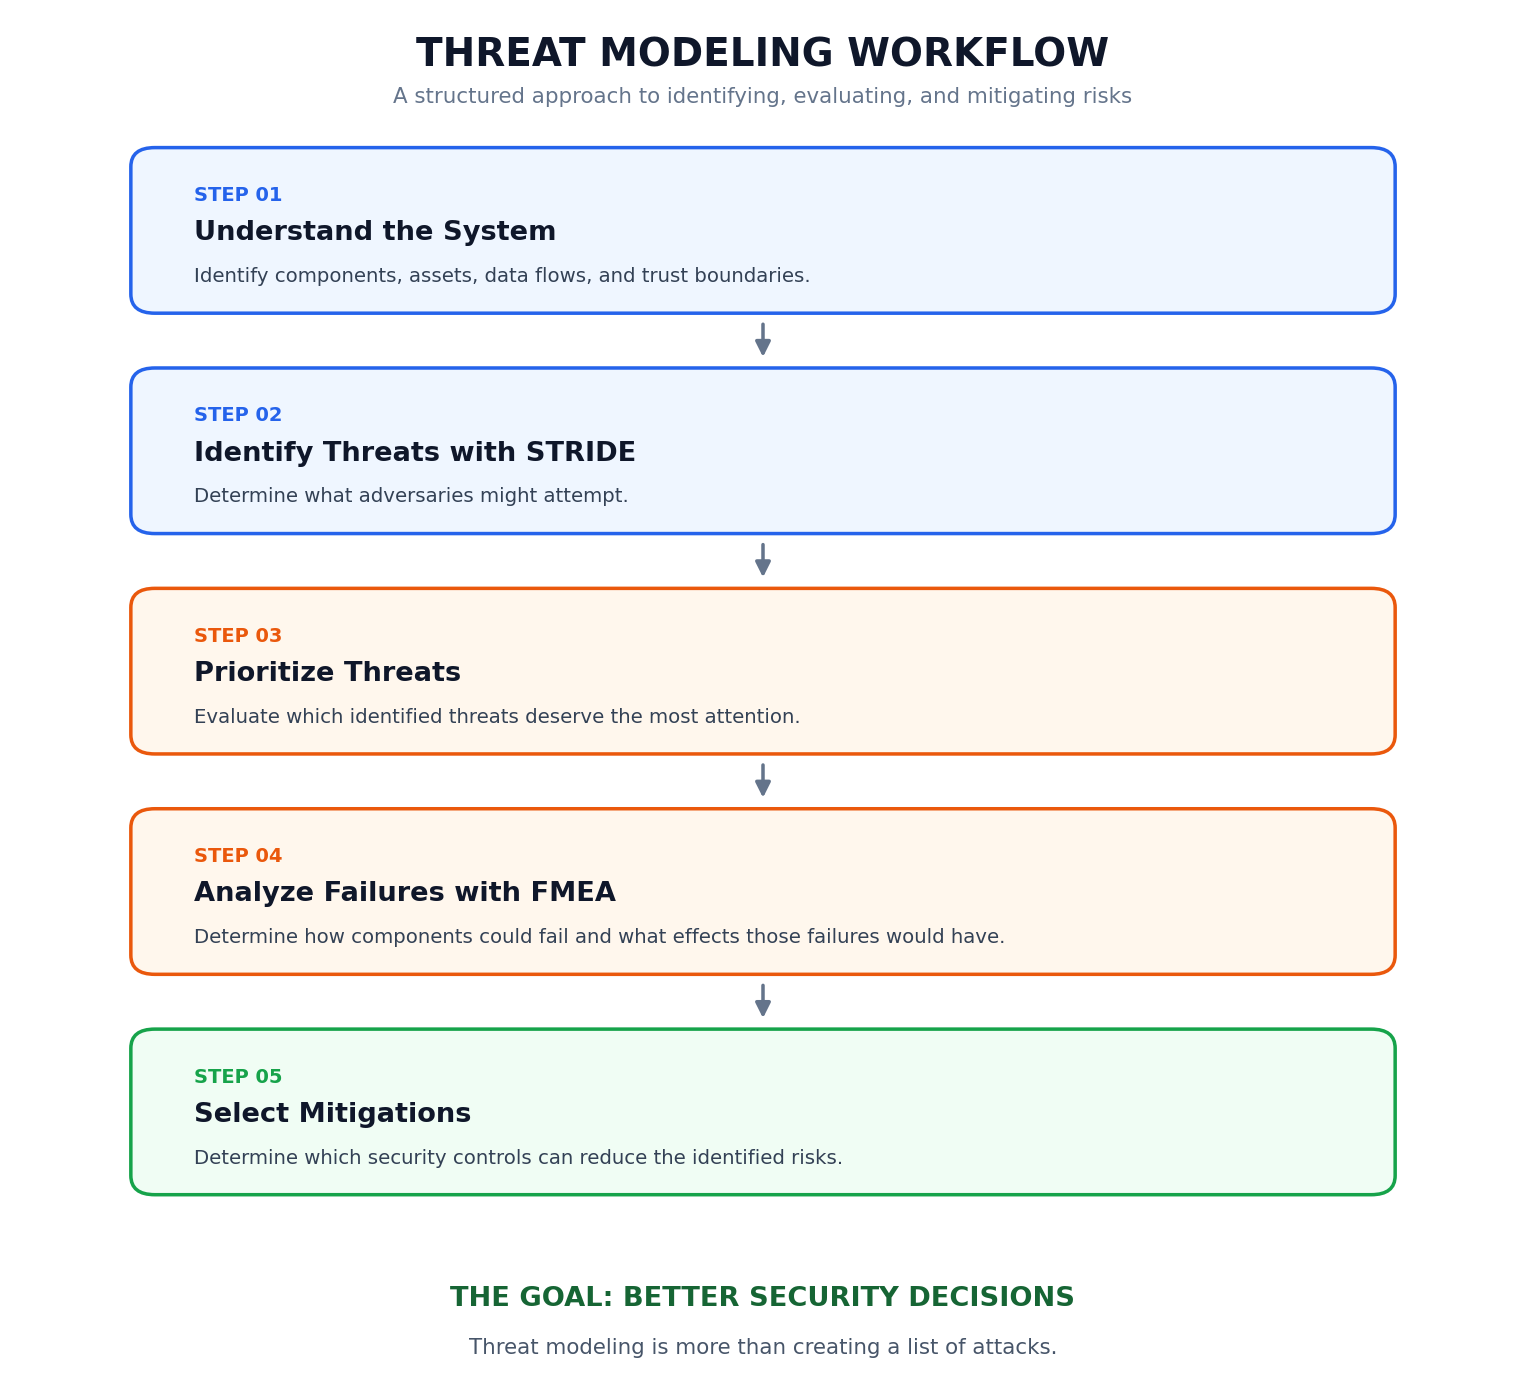

In [4]:
# @title Threat Modeling Workflow { display-mode: "form" }

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
from io import BytesIO
import base64

# ============================================================
# WORKFLOW CONTENT
# ============================================================

steps = [
    (
        "01",
        "Understand the System",
        "Identify components, assets, data flows, and trust boundaries."
    ),
    (
        "02",
        "Identify Threats with STRIDE",
        "Determine what adversaries might attempt."
    ),
    (
        "03",
        "Prioritize Threats",
        "Evaluate which identified threats deserve the most attention."
    ),
    (
        "04",
        "Analyze Failures with FMEA",
        "Determine how components could fail and what effects those failures would have."
    ),
    (
        "05",
        "Select Mitigations",
        "Determine which security controls can reduce the identified risks."
    )
]

# Blue = Identification
# Orange = Analysis
# Green = Mitigation

colors = [
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#FFF7ED", "#EA580C"),
    ("#FFF7ED", "#EA580C"),
    ("#F0FDF4", "#16A34A")
]

# ============================================================
# CREATE WORKFLOW DIAGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor("white")

ax.set_xlim(0, 10)
ax.set_ylim(0, 11.4)
ax.axis("off")

# Title
ax.text(
    5, 11.05,
    "THREAT MODELING WORKFLOW",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#0F172A"
)

# Subtitle
ax.text(
    5, 10.65,
    "A structured approach to identifying, evaluating, and mitigating risks",
    ha="center",
    fontsize=11,
    color="#64748B"
)

# ============================================================
# DRAW WORKFLOW STEPS
# ============================================================

for i, (number, title, description) in enumerate(steps):

    y = 8.9 - i * 1.85
    bg, accent = colors[i]

    # Rounded workflow card
    card = FancyBboxPatch(
        (0.8, y),
        8.4,
        1.35,
        boxstyle="round,pad=0.02,rounding_size=0.16",
        facecolor=bg,
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    # Step number
    ax.text(
        1.2,
        y + 0.93,
        f"STEP {number}",
        fontsize=10,
        fontweight="bold",
        color=accent
    )

    # Step title
    ax.text(
        1.2,
        y + 0.60,
        title,
        fontsize=14,
        fontweight="bold",
        color="#0F172A"
    )

    # Step description
    ax.text(
        1.2,
        y + 0.25,
        description,
        fontsize=10.2,
        color="#334155"
    )

    # Connecting arrow
    if i < len(steps) - 1:

        arrow = FancyArrowPatch(
            (5, y - 0.08),
            (5, y - 0.42),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.8,
            color="#64748B"
        )

        ax.add_patch(arrow)

# ============================================================
# FINAL TAKEAWAY
# ============================================================

ax.text(
    5,
    0.55,
    "THE GOAL: BETTER SECURITY DECISIONS",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color="#166534"
)

ax.text(
    5,
    0.15,
    "Threat modeling is more than creating a list of attacks.",
    ha="center",
    fontsize=11,
    color="#475569"
)

plt.tight_layout()

# ============================================================
# CONVERT DIAGRAM TO EMBEDDED IMAGE
# ============================================================

buffer = BytesIO()

fig.savefig(
    buffer,
    format="png",
    dpi=140,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig)

image_data = base64.b64encode(
    buffer.getvalue()
).decode("utf-8")

buffer.close()

# ============================================================
# DISPLAY COLLAPSIBLE WORKFLOW
# ============================================================

display(HTML(f"""
<details style="
    margin:12px 0;
    border:1px solid #bfdbfe;
    border-radius:10px;
    overflow:hidden;
">

    <summary style="
        cursor:pointer;
        font-size:16px;
        font-weight:bold;
        padding:16px;
        background:#eff6ff;
        color:#1e3a8a;
        border-left:5px solid #2563eb;
    ">
        Threat Modeling Workflow — Click to Expand
    </summary>

    <div style="
        padding:15px;
        background:white;
        text-align:center;
    ">

        <img
            src="data:image/png;base64,{image_data}"
            style="
                width:100%;
                max-width:900px;
                height:auto;
            "
        >

        <div style="
            max-width:750px;
            margin:15px auto;
            padding:16px;
            background:#f8fafc;
            border-radius:8px;
            color:#334155;
            font-size:14px;
            line-height:1.7;
            text-align:left;
        ">

            Threat modeling is therefore not simply about
            creating a list of attacks.

            <br><br>

            The ultimate goal is to help defenders make
            <b style="color:#2563eb;">
                better security decisions.
            </b>

        </div>

    </div>

</details>
"""))

<details>

<summary><b>STRIDE + DREAD + FMEA — Click to Expand</b></summary>

<br>

So far, you have practiced **STRIDE**, **DREAD**, and **FMEA** separately.

In this activity, you will combine all three approaches to analyze a single AI security scenario.

Remember that each approach answers a different question:

**STRIDE**

> What type of security threat are we dealing with?

**DREAD**

> How should we evaluate and prioritize the identified threat?

**FMEA**

> How could the system fail, and what would the consequences be?

You will work through a simplified attack against an **AI-based phishing detection system**.

### Scenario

An organization uses a machine learning model to classify incoming emails as either **Phishing** or **Legitimate**.

The model is periodically retrained using emails collected by the organization.

An attacker gains unauthorized access to part of the training dataset.

The attacker changes the labels of several phishing emails from:

**Phishing → Legitimate**

The next time the model is trained, it learns from the manipulated data.

After deployment, some phishing emails are incorrectly classified as legitimate and are allowed to reach users.

Your job is to analyze this scenario using:

1. STRIDE
2. DREAD
3. FMEA

Run each activity below and answer the questions based on the scenario.

</details>

In [ ]:
# @title ▶ Part 1 — Identify the STRIDE Threat { display-mode: "form" }

print("=== STRIDE Analysis ===\n")

print("Scenario:")
print("""
An attacker gains unauthorized access to a training
dataset and changes several email labels from
'Phishing' to 'Legitimate'.
""")

print("Which STRIDE category BEST describes the attack?\n")

options = {
    "S": "Spoofing",
    "T": "Tampering",
    "R": "Repudiation",
    "I": "Information Disclosure",
    "D": "Denial of Service",
    "E": "Elevation of Privilege"
}

for letter, category in options.items():
    print(f"{letter}: {category}")

answer = input("\nYour answer: ").strip().upper()

print("\n=== Result ===")

if answer == "T":
    print("Correct!")
    print("\nThe attacker intentionally modified the training data.")
    print("This is primarily a Tampering threat.")
else:
    print("Not quite.")
    print("\nThe best answer is T — Tampering.")
    print("The attacker modified information without authorization.")

<details>

<summary><b>Part 1 Explanation — Click to Expand</b></summary>

<br>

The attack is primarily classified as **Tampering**.

Tampering involves the unauthorized modification of information or system components.

In this scenario, the attacker changes:

**Phishing → Legitimate**

inside the training dataset.

The dataset is therefore no longer trustworthy.

STRIDE helped us answer our first question:

> **What type of security threat occurred?**

### STRIDE Result

| Item | Result |
|---|---|
| Asset | Training Dataset |
| Threat | Unauthorized label modification |
| STRIDE Category | Tampering |
| Security Property Affected | Integrity |

Now that the threat has been identified, the next step is to evaluate how important the threat may be.

</details>

In [ ]:
# @title ▶ Part 2 — Evaluate the Threat with DREAD { display-mode: "form" }

print("=== DREAD Risk Assessment ===\n")

print("Threat:")
print("An attacker modifies phishing labels in the training dataset.\n")

print("Rate each category from 1 (Low) to 10 (High).\n")

def get_score(category, description):
    while True:
        try:
            print(f"\n{category}")
            print(description)

            score = int(input("Score (1-10): "))

            if 1 <= score <= 10:
                return score

            print("Please enter a value between 1 and 10.")

        except ValueError:
            print("Please enter a number.")

damage = get_score(
    "Damage",
    "How serious would the consequences be if the attack succeeded?"
)

reproducibility = get_score(
    "Reproducibility",
    "How consistently could the attack be repeated?"
)

exploitability = get_score(
    "Exploitability",
    "How difficult would the attack be to perform?"
)

affected_users = get_score(
    "Affected Users",
    "How many users or systems could be affected?"
)

discoverability = get_score(
    "Discoverability",
    "How easily could an attacker identify this weakness?"
)

scores = {
    "Damage": damage,
    "Reproducibility": reproducibility,
    "Exploitability": exploitability,
    "Affected Users": affected_users,
    "Discoverability": discoverability
}

average = sum(scores.values()) / len(scores)

print("\n=== Your DREAD Assessment ===")

for category, score in scores.items():
    print(f"{category}: {score}/10")

print(f"\nAverage DREAD Score: {average:.1f}/10")

if average >= 8:
    priority = "High"
elif average >= 5:
    priority = "Medium"
else:
    priority = "Low"

print("Estimated Priority:", priority)

print("\nRemember: The score is only useful if you can")
print("explain why you selected each value.")

<details>

<summary><b>Part 2 Explanation — Click to Expand</b></summary>

<br>

DREAD adds another layer to the analysis.

STRIDE identified the attack as **Tampering**, but STRIDE does not tell us how important that threat should be compared with other threats.

DREAD asks you to consider several characteristics of the attack.

### Damage

Consider what could happen if poisoned training data causes phishing emails to bypass the classifier.

### Reproducibility

Consider whether an attacker with the necessary access could perform the attack repeatedly.

### Exploitability

Consider how much access, knowledge, and technical ability the attacker would need.

### Affected Users

Consider how many users could receive phishing emails because of the compromised model.

### Discoverability

Consider how easily an attacker could identify the opportunity to manipulate the training dataset.

There is **not necessarily one perfect set of scores**.

Two analysts may choose different values based on their assumptions about the system.

What matters is that the scores can be **supported with reasonable security justification**.

DREAD helped us answer:

> **How significant might this threat be?**

</details>

In [ ]:
# @title ▶ Part 3 — Analyze the Failure with FMEA { display-mode: "form" }

print("=== Failure Modes and Effects Analysis ===\n")

print("Scenario:")
print("""
Poisoned training data causes the model to classify
some phishing emails as legitimate.
""")

print("Failure Mode:")
print("Phishing email is classified as legitimate.")

print("\nPossible Effect:")
print("A malicious email reaches the user.")

print("\nPossible Cause:")
print("Training labels were intentionally manipulated.")

print("\nRate each category from 1 (Low) to 10 (High).\n")

def get_score(category, description):
    while True:
        try:
            print(f"\n{category}")
            print(description)

            score = int(input("Score (1-10): "))

            if 1 <= score <= 10:
                return score

            print("Please enter a value between 1 and 10.")

        except ValueError:
            print("Please enter a number.")

severity = get_score(
    "Severity",
    "How serious would this failure be?"
)

occurrence = get_score(
    "Occurrence",
    "How likely is this failure to occur?"
)

detection = get_score(
    "Detection",
    "How difficult would this failure be to detect before causing harm?"
)

rpn = severity * occurrence * detection

print("\n=== Your FMEA Assessment ===")

print("Failure Mode: Phishing classified as legitimate")
print("Effect: Malicious email reaches the user")
print("Cause: Manipulated training labels")

print(f"\nSeverity: {severity}/10")
print(f"Occurrence: {occurrence}/10")
print(f"Detection: {detection}/10")

print(f"\nRisk Priority Number (RPN): {rpn}")

print("\nRPN = Severity × Occurrence × Detection")

<details>

<summary><b>Part 3 Explanation — Click to Expand</b></summary>

<br>

FMEA changes the perspective of the analysis.

With STRIDE, we focused on the **attacker's action**:

> An attacker modifies training data.

With FMEA, we focus on the **system failure**:

> The AI model incorrectly classifies a phishing email as legitimate.

The analysis can be summarized as:

| FMEA Element | Analysis |
|---|---|
| Failure Mode | Phishing classified as legitimate |
| Effect | Malicious email reaches the user |
| Possible Cause | Poisoned training labels |
| Severity | Student-assigned |
| Occurrence | Student-assigned |
| Detection | Student-assigned |
| RPN | Severity × Occurrence × Detection |

Notice that the **cause and failure mode are not the same thing**.

The poisoned training data contributes to the failure.

The failure itself is the incorrect classification.

The effect is what happens because of that failure.

FMEA therefore helps answer:

> **How could the system fail, and what would happen if it did?**

</details>

In [ ]:
# @title ▶ Part 4 — Build the Combined Threat Analysis { display-mode: "form" }

print("=== Combined AI Threat Analysis ===\n")

print("SYSTEM:")
print("AI-Based Phishing Detection System")

print("\nASSET:")
print("Training Dataset")

print("\nTHREAT:")
print("Attacker modifies phishing training labels.")

print("\nSTRIDE:")
print("Tampering")

print("\nDREAD:")
print(f"Risk Score: {average:.1f}/10")
print(f"Priority: {priority}")

print("\nFMEA:")
print("Failure Mode: Phishing classified as legitimate")
print("Effect: Malicious email reaches user")
print("Cause: Manipulated training labels")
print(f"RPN: {rpn}")

print("\n" + "=" * 50)

print("\nSTRIDE → What type of threat is it?")
print("DREAD  → How should we prioritize the threat?")
print("FMEA   → How could the system fail?")

print("\n" + "=" * 50)

print("\nNext Step: MITIGATION")
print("What controls could reduce this risk?")

<details>

<summary><b>Combined Explanation — Click to Expand</b></summary>

<br>

You have now examined the **same AI security problem from three different perspectives**.

### Step 1 — STRIDE

You identified the attack as:

**Tampering**

This described what the attacker did to the system.

---

### Step 2 — DREAD

You evaluated characteristics such as:

- Damage
- Reproducibility
- Exploitability
- Affected Users
- Discoverability

This helped you think about the **relative importance of the threat**.

---

### Step 3 — FMEA

You identified:

**Failure Mode:** Phishing classified as legitimate

**Effect:** Malicious email reaches the user

**Cause:** Manipulated training labels

You then evaluated the failure using Severity, Occurrence, and Detection.

---

### The Complete Analysis

The process can now be viewed as:

```text
AI System
    ↓
Identify Asset
    ↓
Identify Threat
    ↓
STRIDE
"What type of threat is this?"
    ↓
DREAD
"How should we prioritize it?"
    ↓
FMEA
"How could the system fail?"
    ↓
Mitigation
"What should we do about it?"

<details>

<summary><b>Part 5 — Student Mitigation Challenge — Click to Expand</b></summary>

<br>

You have now used **STRIDE, DREAD, and FMEA** to analyze the scenario.

Your final step is to think like a defender and determine how the identified risk could be reduced.

### Scenario Reminder

An attacker gained unauthorized access to the training dataset and changed several email labels from:

**Phishing → Legitimate**

The poisoned dataset was then used to retrain the model.

As a result, some phishing emails were incorrectly classified as legitimate.

### Your Task

You will recommend **three security controls** that could help prevent, detect, or reduce the impact of this attack.

When you run the activity below, you will be given several possible security controls to consider.

You are not required to choose from the examples. You may recommend another appropriate control if you can explain how it would help.

There may be **multiple correct answers**.

The goal is to demonstrate that you can connect a security control to the threat you identified.

</details>

In [ ]:
# @title ▶ Part 5 — Recommend Security Controls { display-mode: "form" }

print("=== Mitigation Challenge ===\n")

print("SCENARIO:")
print("""
An attacker gains unauthorized access to the training
dataset and changes phishing labels to legitimate.

The poisoned dataset is later used to retrain the model,
causing some phishing emails to bypass detection.
""")

print("=" * 55)

print("\nPossible controls to consider:\n")

controls = [
    "1. Restrict access to training datasets",
    "2. Validate training labels before training",
    "3. Track dataset versions and changes",
    "4. Verify dataset provenance",
    "5. Monitor model performance",
    "6. Log changes made to training data",
    "7. Require approval before new datasets are used",
    "8. Another control of your choice"
]

for control in controls:
    print(control)

print("\n" + "=" * 55)

responses = []

for i in range(1, 4):

    print(f"\n--- Recommendation {i} ---")

    control = input(
        "Which security control would you recommend? "
    ).strip()

    reason = input(
        "How would this control help prevent, detect, "
        "or reduce the attack? "
    ).strip()

    responses.append({
        "control": control,
        "reason": reason
    })

print("\n" + "=" * 55)
print("YOUR MITIGATION PLAN")
print("=" * 55)

for i, response in enumerate(responses, 1):

    print(f"\nRecommendation {i}")
    print("Control:", response["control"])
    print("How it helps:", response["reason"])

print("\n" + "=" * 55)

reflection = input(
    "\nIn 1-2 sentences, explain why using STRIDE, DREAD, "
    "and FMEA together gives defenders more information "
    "than using only one approach:\n\n"
)

print("\n=== Final Reflection ===")
print(reflection)

print("\nActivity Complete!")

<details>

<summary><b>Part 5 Review — Click to Expand After Completing the Activity</b></summary>

<br>

There are several reasonable ways to reduce the risk presented in this scenario.

For example:

### Restrict Access to Training Data

Strong access controls can limit who is authorized to modify the training dataset.

This addresses the attack close to its source by making unauthorized modification more difficult.

---

### Validate Training Labels

Training data can be checked for suspicious or unexpected label changes before it is accepted for model training.

This could help identify manipulated records before the model learns from them.

---

### Dataset Versioning

Maintaining versions of important datasets allows defenders to compare changes and potentially restore a known-good version if unauthorized modifications are discovered.

---

### Logging and Auditing

Recording who modifies training data, what was changed, and when the change occurred can help defenders investigate suspicious activity.

This is also useful for addressing **Repudiation** concerns identified through STRIDE.

---

### Model Performance Monitoring

Monitoring model performance after retraining could help defenders notice unexpected changes in classification behavior.

For example, a sudden increase in phishing emails being classified as legitimate could indicate a problem requiring investigation.

---

## Connecting the Entire Exercise

Your analysis should now follow a basic progression:

**STRIDE**

Identified the attack as **Tampering** because the attacker modified training data.

↓

**DREAD**

Helped evaluate and prioritize the identified threat.

↓

**FMEA**

Examined the resulting failure:

**Phishing email → Incorrectly classified as legitimate → Reaches the user**

↓

**Mitigation**

Identified security controls that could **prevent, detect, or reduce the impact of the attack**.

The important lesson is that threat modeling should ultimately lead to action.

Identifying a threat is useful, but defenders must also determine:

> **What security controls can we implement to reduce the risk?**

</details>

---

<details>

<summary><b>Section 7 — From Threat Model to Security Controls — Click to Expand</b></summary>

<br>

Identifying threats is only useful if the results of the threat model lead to security improvements.

After using techniques such as **STRIDE, DREAD, and FMEA**, defenders should have a clearer understanding of:

- What assets need protection
- How attackers could target the system
- Which threats deserve the most attention
- How the system could fail
- What consequences those failures could create

The next step is deciding:

> **What security controls can reduce these risks?**

Security controls can be implemented at different points in the AI lifecycle and can serve different purposes.

Some controls attempt to prevent attacks from occurring. Others help defenders detect suspicious activity, respond to incidents, or recover after something has gone wrong.

A strong threat model should therefore connect identified threats directly to appropriate security controls.

---

<details>

<summary><b>7.1 — Preventive Controls</b></summary>

<br>

**Preventive controls** attempt to stop an attack or failure before it occurs.

For example, consider the training-data tampering scenario from Section 6.

The identified threat was:

> **An attacker modifies labels inside the training dataset.**

One preventive control would be to restrict who can modify the dataset.

If only authorized users and services have permission to make changes, it becomes more difficult for an attacker to manipulate the training information.

Other examples of preventive controls for AI systems include:

- Strong authentication
- Role-based access control
- Least privilege
- Input validation
- Dataset validation
- Data provenance requirements
- Dependency verification
- Model integrity verification
- Approval requirements before model deployment
- Secure configuration management

Preventive controls are important because they attempt to reduce the likelihood that an identified threat will succeed.

However, defenders should not assume that prevention will always work.

An attacker may compromise an authorized account, discover a new vulnerability, or find another way around the preventive control.

For this reason, preventive controls should normally be supported by additional layers of security.

</details>

---

<details>

<summary><b>7.2 — Detective Controls</b></summary>

<br>

**Detective controls** help identify suspicious activity, attacks, or failures that may already be occurring.

Consider the same training-data tampering scenario.

Even if access controls are implemented, defenders may also want to monitor changes made to the dataset.

A logging system could record:

- Who modified the dataset
- What records were changed
- When the changes occurred
- Which labels were modified
- Which dataset version was used for training

Unexpected changes could then trigger further investigation.

Examples of detective controls in AI environments include:

- Security logging
- Dataset change monitoring
- Model performance monitoring
- Anomaly detection
- API usage monitoring
- Authentication monitoring
- Model integrity checks
- Alerts for unexpected configuration changes
- Monitoring unusual prediction patterns

Detective controls are especially important because defenders cannot assume every attack will be prevented.

The faster suspicious behavior is detected, the faster defenders may be able to respond.

</details>

---

<details>

<summary><b>7.3 — Corrective and Recovery Controls</b></summary>

<br>

Some security controls help organizations respond after a security problem has already occurred.

These can be considered **corrective or recovery controls**.

Return to the training-data example.

Suppose defenders discover that the training dataset was manipulated and that a compromised model has already been deployed.

The organization may need to:

1. Remove the compromised model.
2. Restore a trusted version of the dataset.
3. Determine which records were modified.
4. Retrain the model using verified data.
5. Test the new model.
6. Redeploy the trusted version.
7. Investigate how the attacker gained access.

Examples of corrective and recovery controls include:

- Dataset backups
- Dataset versioning
- Model versioning
- Rollback procedures
- Incident response procedures
- Known-good model checkpoints
- Recovery testing
- Retraining procedures

AI systems therefore need recovery planning just like traditional information systems.

Organizations should consider not only how to protect a model, but also:

> **What will we do if the model or its supporting data can no longer be trusted?**

</details>

---

<details>

<summary><b>7.4 — Defense in Depth</b></summary>

<br>

A single security control should rarely be the only protection against an important threat.

**Defense in depth** uses multiple security controls so that the failure of one control does not automatically result in a successful attack.

Consider training-data tampering.

An organization might implement:

**Layer 1 — Access Control**

Only authorized accounts can modify the training dataset.

**Layer 2 — Logging**

Every modification to the dataset is recorded.

**Layer 3 — Dataset Versioning**

Previous trusted versions of the dataset are retained.

**Layer 4 — Validation**

Training data is checked before being accepted for model training.

**Layer 5 — Model Testing**

The newly trained model is evaluated before deployment.

**Layer 6 — Monitoring**

Model behavior is monitored after deployment.

If an attacker bypasses one layer, another control may still prevent or detect the attack.

This is why threat modeling should not simply produce:

> **Threat → One Control**

A stronger approach is:

> **Threat → Multiple Complementary Controls**

</details>

---

<details>

<summary><b>7.5 — Connecting Controls to Identified Threats</b></summary>

<br>

Every recommended security control should have a reason for being included.

A useful threat-model entry might look like:

| Threat | Security Control | Purpose |
|---|---|---|
| Training data tampering | Restrict dataset modification | Prevention |
| Training data tampering | Log dataset changes | Detection |
| Training data tampering | Dataset versioning | Recovery |
| Model API abuse | Rate limiting | Prevention |
| Model API abuse | Query monitoring | Detection |
| Model theft | Access control | Prevention |

This creates traceability between:

**Threat → Risk → Control**

Instead of adding security controls simply because they are considered "best practices," defenders can explain which identified risks those controls are intended to address.

This also helps organizations prioritize limited security resources.

Higher-priority risks identified during threat modeling may justify stronger or additional controls.

</details>

---

<details>

<summary><b>7.6 — Residual Risk</b></summary>

<br>

Security controls can reduce risk, but they rarely eliminate it completely.

The risk that remains after controls have been implemented is commonly called **residual risk**.

For example, an organization might protect its training dataset with:

- Authentication
- Role-based access control
- Logging
- Dataset validation
- Version control

These controls significantly reduce the risk of training-data tampering.

However, risk still exists.

An attacker might compromise an authorized account.

A malicious insider might already possess legitimate access.

A new vulnerability might allow an attacker to bypass an existing control.

The organization therefore needs to consider:

> **What risk remains after our security controls are implemented?**

This is another reason monitoring and continuous threat modeling are important.

Security is not a state where all risk disappears.

The goal is to understand risk and reduce it to an acceptable level.

</details>

</details>

In [ ]:
# @title ▶ Hands-On Activity — Match Threats to Security Controls { display-mode: "form" }

print("=== From Threats to Security Controls ===\n")

scenarios = [
    {
        "threat": "An attacker modifies labels in the training dataset.",
        "options": [
            "A. Restrict dataset modification and monitor changes",
            "B. Increase the number of model classes",
            "C. Increase the training batch size",
            "D. Remove all system logs"
        ],
        "answer": "A"
    },

    {
        "threat": "An attacker sends a large number of requests to the model API.",
        "options": [
            "A. Remove authentication",
            "B. Rate limiting and API monitoring",
            "C. Increase the training dataset size",
            "D. Change the training labels"
        ],
        "answer": "B"
    },

    {
        "threat": "A deployed model is discovered to have been compromised.",
        "options": [
            "A. Continue using the model",
            "B. Disable logging",
            "C. Roll back to a verified model version",
            "D. Allow additional API queries"
        ],
        "answer": "C"
    }
]

score = 0

for i, scenario in enumerate(scenarios, 1):

    print(f"\n--- Scenario {i} ---")
    print(scenario["threat"])

    print("\nWhich control would BEST help address this threat?\n")

    for option in scenario["options"]:
        print(option)

    response = input("\nYour answer: ").strip().upper()

    if response == scenario["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Not quite. Best answer: {scenario['answer']}")

print("\n" + "=" * 50)
print(f"Score: {score}/{len(scenarios)}")

<details>

<summary><b>Hands-On Learning Context — Click to Expand</b></summary>

<br>

This activity demonstrates how the results of a threat model can be translated into **security decisions**.

Notice that the recommended control depends on the threat.

### Training Data Tampering

Restricting modification permissions can help **prevent** unauthorized changes.

Monitoring changes can help **detect** suspicious modifications.

---

### Model API Abuse

Rate limiting can reduce how quickly an attacker can submit requests.

API monitoring can help defenders identify unusual query behavior.

---

### Compromised Model

Model versioning and rollback procedures provide a way to **recover** from a compromised deployment.

---

The important lesson is that security controls should be selected because they address an **identified threat or failure**.

A mature threat model should therefore move from:

**Identify the Threat**

↓

**Evaluate the Risk**

↓

**Understand the Failure**

↓

**Select Security Controls**

↓

**Evaluate Remaining Risk**

This connects the analysis performed in Section 6 with actual defensive actions.

</details>

In [ ]:
# @title ▶ Section 7 Checkpoint — From Threat Model to Security Controls { display-mode: "form" }

questions = [
    {
        "question": "1. What is the primary purpose of a preventive security control?",
        "options": [
            "A. Identify an attack after it succeeds",
            "B. Attempt to stop an attack or failure before it occurs",
            "C. Calculate an FMEA score",
            "D. Identify a STRIDE category"
        ],
        "answer": "B"
    },

    {
        "question": "2. Which is an example of a detective control?",
        "options": [
            "A. Monitoring changes made to a training dataset",
            "B. Increasing model accuracy",
            "C. Increasing the training batch size",
            "D. Removing audit logs"
        ],
        "answer": "A"
    },

    {
        "question": "3. Dataset versioning could help an organization do what after discovering poisoned training data?",
        "options": [
            "A. Increase API traffic",
            "B. Restore a known-good version",
            "C. Remove authentication",
            "D. Increase the number of model classes"
        ],
        "answer": "B"
    },

    {
        "question": "4. What does defense in depth mean?",
        "options": [
            "A. Relying on one strong security control",
            "B. Using multiple complementary layers of security",
            "C. Removing unnecessary monitoring",
            "D. Only protecting the deployed model"
        ],
        "answer": "B"
    },

    {
        "question": "5. What is residual risk?",
        "options": [
            "A. Risk that remains after security controls are implemented",
            "B. Risk that has already been completely eliminated",
            "C. The number of STRIDE categories identified",
            "D. The model's prediction error"
        ],
        "answer": "A"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("Your answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print(f"\nFinal Score: {score}/{len(questions)}")

---

<details>

<summary><b>Section 8 — Threat Modeling Best Practices and Continuous Review — Click to Expand</b></summary>

<br>

A threat model should not be treated as a document that is created once and then forgotten.

AI systems change throughout their lifecycle.

New datasets are collected.

Models are retrained.

Software dependencies are updated.

New APIs and integrations are added.

New vulnerabilities and attack techniques are discovered.

Each of these changes can alter the system's attack surface.

Effective AI threat modeling should therefore be treated as an **iterative and continuous security process**.

---

<details>

<summary><b>8.1 — Model the Entire AI Lifecycle</b></summary>

<br>

One of the most important practices when threat modeling AI systems is examining the **entire AI lifecycle**.

Defenders should not focus only on the deployed model.

Important stages may include:

### Data Collection

Where does the training data originate?

Can external users influence it?

Is sensitive information being collected?

### Data Preparation

Who can modify labels?

How is data cleaned?

How are changes tracked?

### Model Training

Who can modify training code?

Where are model checkpoints stored?

Can training infrastructure be accessed by unauthorized users?

### Model Deployment

How is the model moved into production?

How is model integrity verified?

Who can replace or update the deployed model?

### Inference

Who can submit inputs?

What information does the model return?

Can attackers repeatedly query the model?

### Monitoring and Maintenance

How is model behavior monitored?

How are suspicious changes detected?

How are new model versions evaluated?

Threat modeling only one stage may leave significant portions of the attack surface unexplored.

</details>

---

<details>

<summary><b>8.2 — Identify and Revisit Trust Boundaries</b></summary>

<br>

A **trust boundary** exists where information or control moves between areas with different levels of trust.

Trust boundaries deserve special attention because they often represent locations where untrusted information enters a system.

For an AI phishing detector, an important trust boundary exists between:

**External Email Sender → Organization**

The organization does not control the sender.

Incoming email should therefore be treated as untrusted.

Another boundary might exist between:

**External Dataset → Internal Training Environment**

A dataset downloaded from an external source should not automatically receive the same level of trust as internally verified information.

Other AI trust boundaries might include:

- User → Model API
- Internet → Data Collection Pipeline
- Third-Party Model Repository → Internal Environment
- AI Application → External Tool
- Developer → Production Environment

Trust boundaries should also be revisited when systems change.

Adding a new API, external model, data source, or integration may create an entirely new trust boundary.

</details>

---

<details>

<summary><b>8.3 — Document Security Assumptions</b></summary>

<br>

Threat models depend on assumptions about how a system operates.

These assumptions should be documented.

For example:

> **Assumption: Only authorized administrators can modify the training dataset.**

The threat model may recommend access controls based on that assumption.

But what happens if another application also receives permission to modify the dataset?

The original assumption is no longer accurate.

Other assumptions might include:

- Model APIs require authentication.
- Training datasets come from trusted sources.
- Only approved models can enter production.
- Logs cannot be modified by normal users.
- Model repositories are protected.
- External users cannot access training infrastructure.

Documenting assumptions makes it easier to identify when system changes require the threat model to be updated.

An undocumented assumption can easily become an overlooked security weakness.

</details>

---

<details>

<summary><b>8.4 — Prioritize Rather Than Attempt to Eliminate Every Risk</b></summary>

<br>

Threat modeling may identify many possible threats.

Organizations rarely have unlimited time, personnel, or resources to address every possible risk immediately.

Risk assessment helps determine which threats should receive attention first.

For example, defenders might identify:

- Training-data poisoning
- Model extraction
- API denial of service
- Unauthorized model replacement
- Sensitive data exposure
- Dependency compromise

These threats may not all have the same likelihood or impact.

Techniques such as the risk scoring introduced earlier in this module can help defenders prioritize their response.

Higher-priority risks may receive stronger controls, more monitoring, or faster remediation.

Lower-priority risks may still be documented and monitored.

The goal of threat modeling is not to claim that all risk has disappeared.

The goal is to make **informed security decisions about identified risk**.

</details>

---

<details>

<summary><b>8.5 — Update the Threat Model When the System Changes</b></summary>

<br>

Threat models should be reviewed whenever meaningful changes are made to the system.

Examples include:

### New Training Data

A new dataset may introduce new data sources, trust relationships, privacy concerns, or poisoning opportunities.

### Model Retraining

A newly trained model may behave differently from the previous version.

### New API

Adding an external interface can create a new entry point for attackers.

### New Third-Party Model

Using a pretrained model introduces another supply-chain dependency.

### New External Tool

Connecting an AI system to databases, email, file systems, or other services can significantly increase the consequences of compromise.

### Infrastructure Changes

Moving from local infrastructure to cloud infrastructure may introduce new components, identities, configurations, and trust boundaries.

When these changes occur, defenders should ask:

> **Does our existing threat model still accurately describe this system?**

If the answer is no, the threat model should be updated.

</details>

---

<details>

<summary><b>8.6 — Monitor for New Threats</b></summary>

<br>

The threat landscape also changes even when the AI system itself does not.

Researchers and attackers may discover new ways to:

- Manipulate models
- Poison datasets
- Extract information
- Abuse model APIs
- Compromise dependencies
- Exploit AI integrations

A threat model created during initial development may therefore become incomplete over time.

Security teams should monitor relevant vulnerability information, threat intelligence, AI security research, and incidents affecting similar technologies.

New information should be evaluated against the existing threat model.

If a newly discovered attack applies to the system, it should be added and evaluated.

</details>

---


          ↺


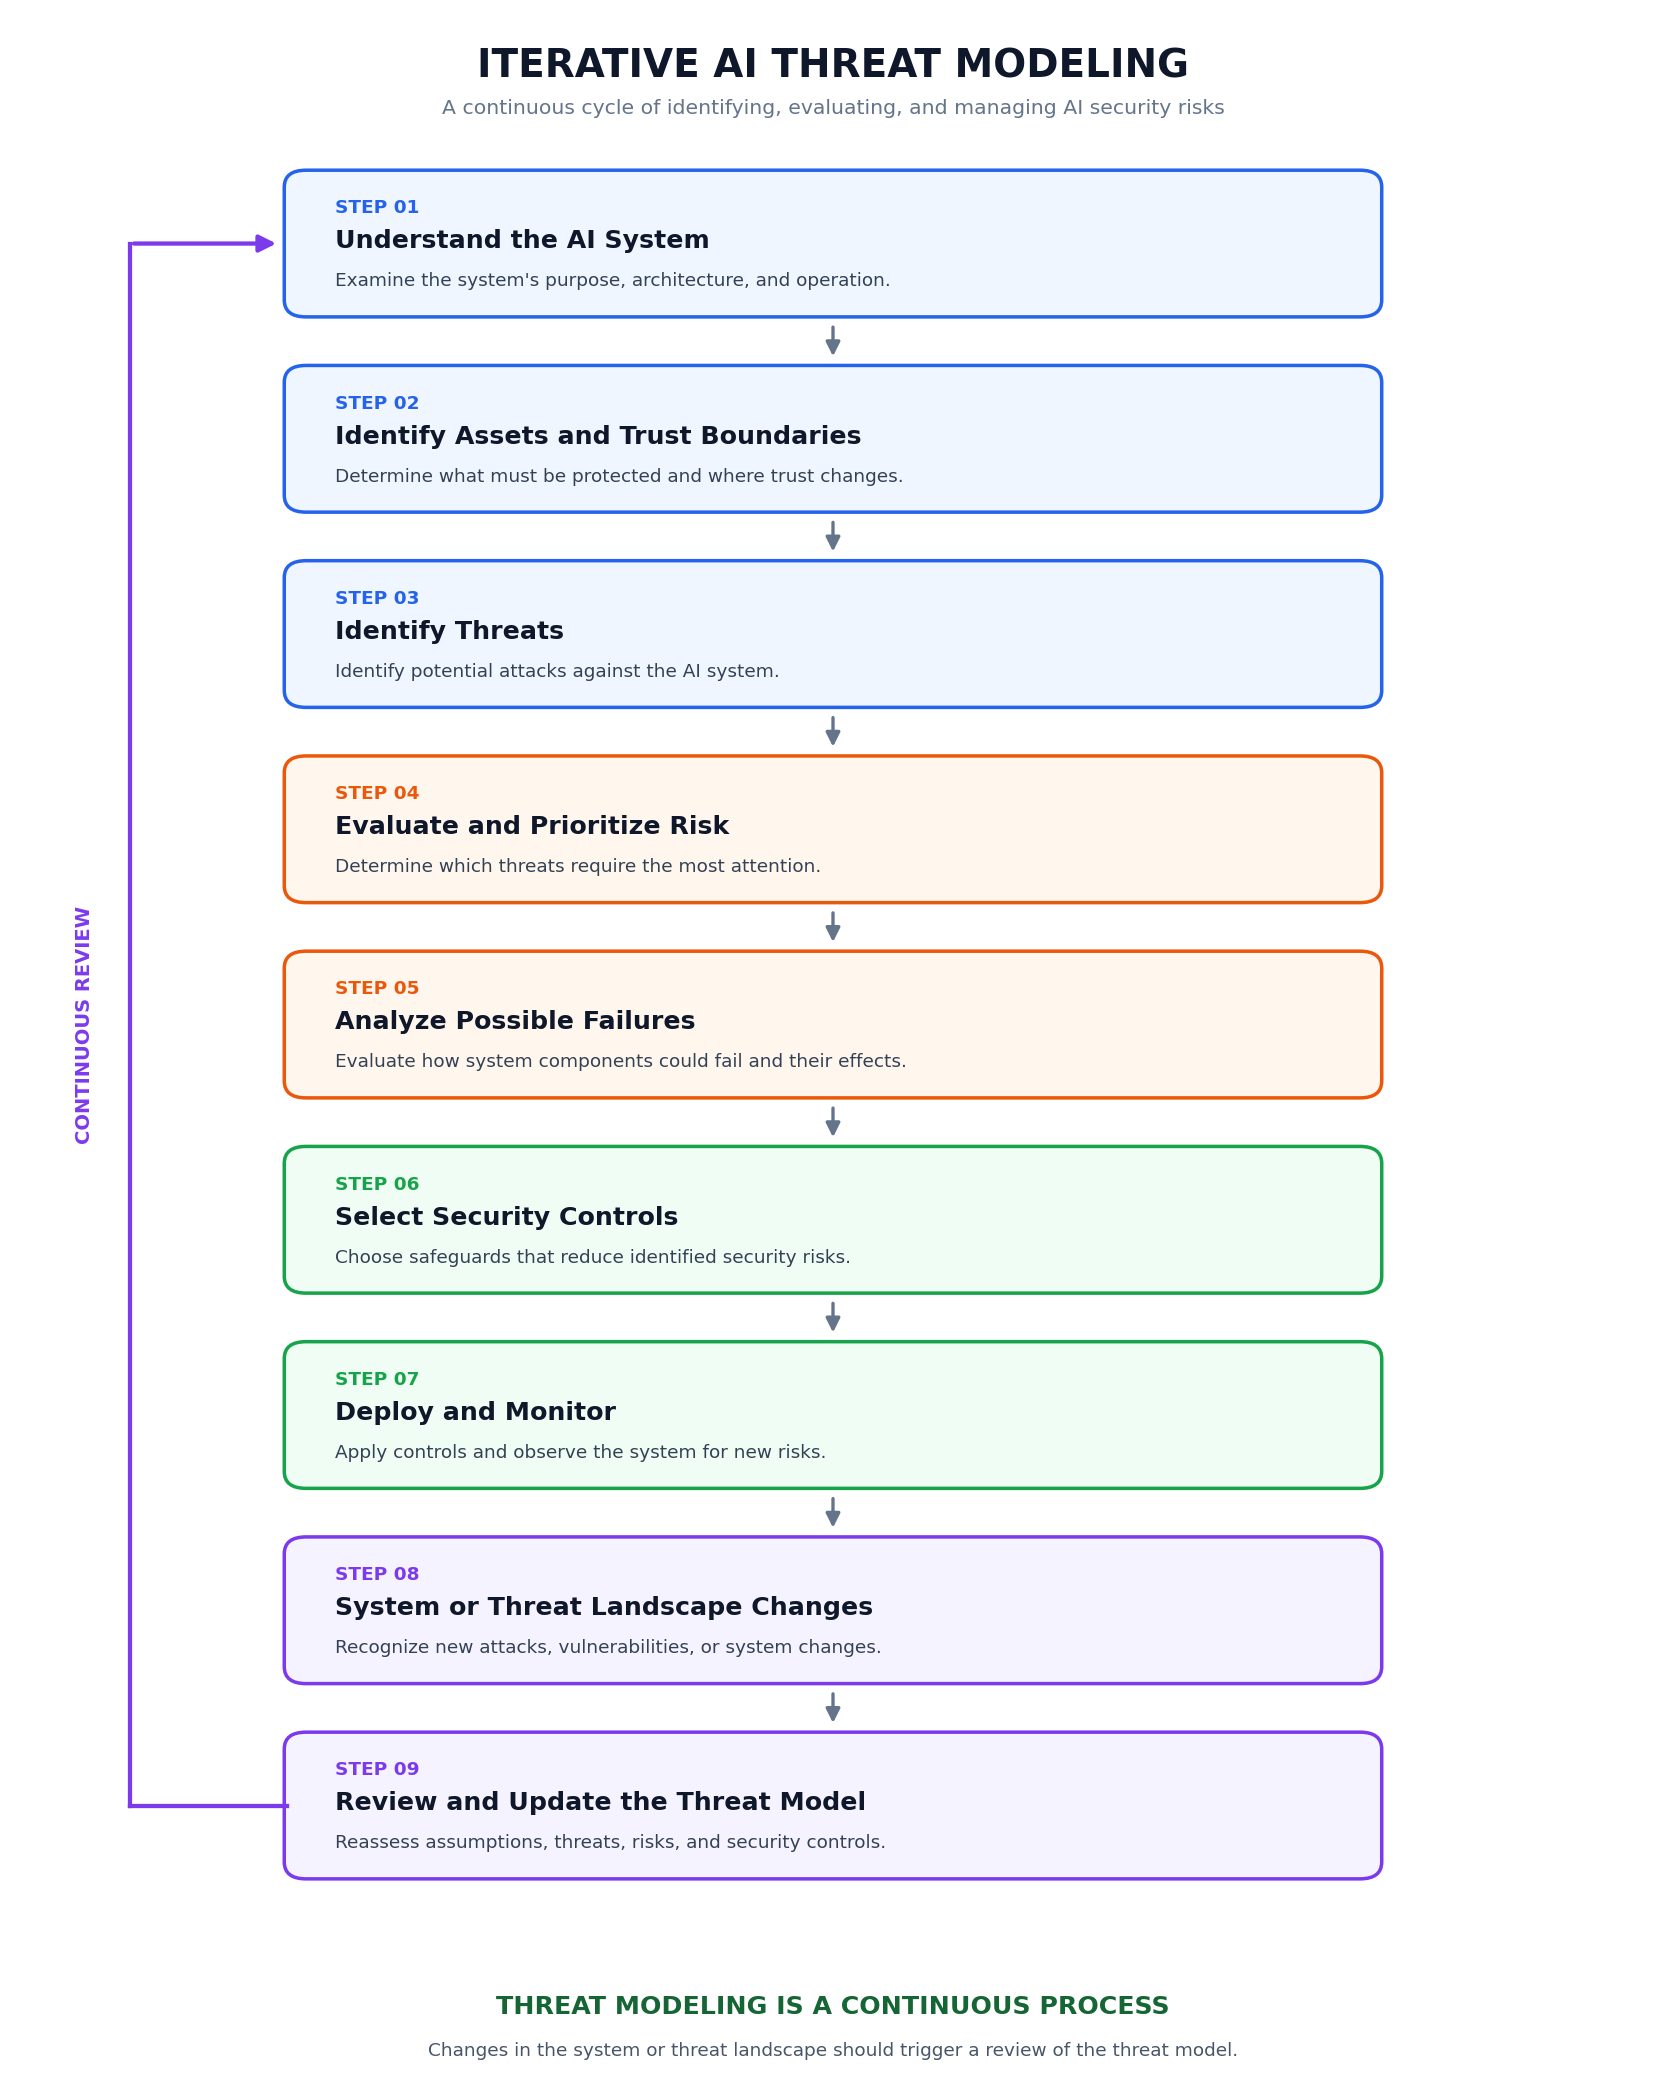

In [5]:
# @title 8.7 — Threat Modeling Is Iterative { display-mode: "form" }

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
from io import BytesIO
import base64
import textwrap

# ============================================================
# WORKFLOW CONTENT
# ============================================================

steps = [
    ("01", "Understand the AI System",
     "Examine the system's purpose, architecture, and operation."),

    ("02", "Identify Assets and Trust Boundaries",
     "Determine what must be protected and where trust changes."),

    ("03", "Identify Threats",
     "Identify potential attacks against the AI system."),

    ("04", "Evaluate and Prioritize Risk",
     "Determine which threats require the most attention."),

    ("05", "Analyze Possible Failures",
     "Evaluate how system components could fail and their effects."),

    ("06", "Select Security Controls",
     "Choose safeguards that reduce identified security risks."),

    ("07", "Deploy and Monitor",
     "Apply controls and observe the system for new risks."),

    ("08", "System or Threat Landscape Changes",
     "Recognize new attacks, vulnerabilities, or system changes."),

    ("09", "Review and Update the Threat Model",
     "Reassess assumptions, threats, risks, and security controls.")
]

# Blue = Understanding and identification
# Orange = Risk and failure analysis
# Green = Controls and monitoring
# Purple = Change and continuous improvement

colors = [
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#FFF7ED", "#EA580C"),
    ("#FFF7ED", "#EA580C"),
    ("#F0FDF4", "#16A34A"),
    ("#F0FDF4", "#16A34A"),
    ("#F5F3FF", "#7C3AED"),
    ("#F5F3FF", "#7C3AED")
]

# ============================================================
# CREATE WORKFLOW DIAGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(12, 15))
fig.patch.set_facecolor("white")

ax.set_xlim(0, 12)
ax.set_ylim(0, 19.5)
ax.axis("off")

ax.text(
    6, 19.0,
    "ITERATIVE AI THREAT MODELING",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#0F172A"
)

ax.text(
    6, 18.55,
    "A continuous cycle of identifying, evaluating, and managing AI security risks",
    ha="center",
    fontsize=10.5,
    color="#64748B"
)

# ============================================================
# DRAW WORKFLOW STEPS
# ============================================================

card_x = 2.0
card_width = 8.0
card_height = 1.35
step_spacing = 1.85
first_y = 16.65

for i, (number, title, description) in enumerate(steps):

    y = first_y - i * step_spacing
    bg, accent = colors[i]

    card = FancyBboxPatch(
        (card_x, y),
        card_width,
        card_height,
        boxstyle="round,pad=0.02,rounding_size=0.16",
        facecolor=bg,
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    ax.text(
        card_x + 0.35,
        y + 0.96,
        f"STEP {number}",
        fontsize=9.5,
        fontweight="bold",
        color=accent
    )

    ax.text(
        card_x + 0.35,
        y + 0.63,
        title,
        fontsize=13,
        fontweight="bold",
        color="#0F172A"
    )

    ax.text(
        card_x + 0.35,
        y + 0.27,
        description,
        fontsize=9.5,
        color="#334155"
    )

    if i < len(steps) - 1:
        ax.add_patch(
            FancyArrowPatch(
                (6, y - 0.08),
                (6, y - 0.43),
                arrowstyle="-|>",
                mutation_scale=15,
                linewidth=1.7,
                color="#64748B"
            )
        )

# ============================================================
# DRAW ITERATIVE FEEDBACK LOOP
# ============================================================

# The final step feeds back into the first step.

top_y = first_y + card_height / 2
bottom_y = first_y - 8 * step_spacing + card_height / 2

loop_color = "#7C3AED"
loop_x = 0.85

# Horizontal line from final step to feedback path
ax.plot(
    [card_x, loop_x],
    [bottom_y, bottom_y],
    color=loop_color,
    linewidth=2.2
)

# Vertical feedback path
ax.plot(
    [loop_x, loop_x],
    [bottom_y, top_y],
    color=loop_color,
    linewidth=2.2
)

# Arrow returning to the first step
ax.add_patch(
    FancyArrowPatch(
        (loop_x, top_y),
        (card_x - 0.05, top_y),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=2.2,
        color=loop_color
    )
)

ax.text(
    0.52,
    (top_y + bottom_y) / 2,
    "CONTINUOUS REVIEW",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color=loop_color,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        pad=5
    )
)

# ============================================================
# FINAL TAKEAWAY
# ============================================================

ax.text(
    6,
    0.55,
    "THREAT MODELING IS A CONTINUOUS PROCESS",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#166534"
)

ax.text(
    6,
    0.15,
    "Changes in the system or threat landscape should trigger a review of the threat model.",
    ha="center",
    fontsize=9.5,
    color="#475569"
)

plt.tight_layout()

# ============================================================
# CONVERT DIAGRAM TO EMBEDDED IMAGE
# ============================================================

buffer = BytesIO()

fig.savefig(
    buffer,
    format="png",
    dpi=140,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig)

image_data = base64.b64encode(
    buffer.getvalue()
).decode("utf-8")

buffer.close()

# ============================================================
# DISPLAY COLLAPSIBLE WORKFLOW
# ============================================================

display(HTML(f"""
<details style="
    margin:12px 0;
    border:1px solid #c4b5fd;
    border-radius:10px;
    overflow:hidden;
">

    <summary style="
        cursor:pointer;
        font-size:16px;
        font-weight:bold;
        padding:16px;
        background:#f5f3ff;
        color:#5b21b6;
        border-left:5px solid #7c3aed;
    ">
        8.7 — Threat Modeling Is Iterative — Click to Expand
    </summary>

    <div style="
        padding:15px;
        background:white;
        text-align:center;
    ">

        <img
            src="data:image/png;base64,{image_data}"
            style="
                width:100%;
                max-width:900px;
                height:auto;
            "
        >

        <div style="
            max-width:750px;
            margin:15px auto;
            padding:16px;
            background:#f8fafc;
            border-radius:8px;
            color:#334155;
            font-size:14px;
            line-height:1.7;
            text-align:left;
        ">

            Threat modeling should be viewed as a
            <b>continuous cycle</b> rather than a one-time task.

            <br><br>

            As AI systems evolve, new vulnerabilities, attack
            techniques, and operational changes can introduce
            security risks that were not present during the
            original assessment.

            <br><br>

            The threat model should therefore be regularly
            reviewed and updated to reflect changes in the
            system and its threat landscape.

            <br><br>

            <b style="color:#7c3aed;">
                The key takeaway: Threat modeling must evolve
                alongside the AI system it protects.
            </b>

        </div>

    </div>

</details>
"""))

In [ ]:
# @title ▶ Section 8 Checkpoint — Threat Modeling Best Practices { display-mode: "form" }

questions = [
    {
        "question": "1. Why should threat modeling examine the entire AI lifecycle?",
        "options": [
            "A. Threats can occur at multiple stages of the system",
            "B. All attacks occur during model training",
            "C. Only datasets require security",
            "D. Deployment removes earlier security risks"
        ],
        "answer": "A"
    },

    {
        "question": "2. What is a trust boundary?",
        "options": [
            "A. The accuracy threshold of a model",
            "B. A location where information or control crosses between different levels of trust",
            "C. A machine learning training technique",
            "D. A type of DREAD score"
        ],
        "answer": "B"
    },

    {
        "question": "3. Why should security assumptions be documented?",
        "options": [
            "A. Assumptions may change as the system changes",
            "B. Assumptions eliminate the need for security controls",
            "C. They increase model accuracy",
            "D. They prevent every possible attack"
        ],
        "answer": "A"
    },

    {
        "question": "4. When should an AI threat model be reviewed?",
        "options": [
            "A. Only after a successful cyberattack",
            "B. Only when the model is first created",
            "C. When meaningful system or threat landscape changes occur",
            "D. Threat models never need to be reviewed"
        ],
        "answer": "C"
    },

    {
        "question": "5. Which statement BEST describes threat modeling?",
        "options": [
            "A. It is a one-time task completed before deployment",
            "B. It is an iterative process that should continue throughout the AI lifecycle",
            "C. It eliminates all cybersecurity risk",
            "D. It only applies to machine learning models"
        ],
        "answer": "B"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("Your answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print(f"\nFinal Score: {score}/{len(questions)}")

---

<details>

<summary><b>Section 9 — End-of-Module Lab: Threat Model an AI-Based Malware Detection System — Click to Expand</b></summary>

<br>

## Lab Overview

Throughout Module 2, you learned how threat modeling can help defenders proactively identify and address security risks in AI systems.

You practiced:

- Identifying assets and attack surfaces
- Identifying trust boundaries
- Using **STRIDE** to classify threats
- Using **DREAD** to evaluate and prioritize threats
- Using **FMEA** to analyze system failures
- Selecting preventive, detective, and corrective security controls
- Considering residual risk
- Updating threat models as systems change

In this lab, you will apply these concepts to a new AI system with less guidance than the previous activities.

---

## Scenario — AI-Based Malware Detection System

An organization has developed a machine learning system that analyzes files uploaded by users and predicts whether each file is:

**Benign**

or

**Malicious**

The organization periodically collects new file samples and adds them to a training dataset.

Security analysts review and label the samples.

The training dataset is then used to train new versions of the malware detection model.

After testing, an approved model is deployed to a cloud-based inference service.

Users and other applications can submit files to the service through an API.

The basic system operates as follows:

```text
                  TRAINING PIPELINE

New File Samples
       ↓
Security Analyst Labeling
       ↓
Training Dataset
       ↓
Model Training
       ↓
Model Testing
       ↓
Model Repository
       ↓
Approved Model
       |
       |
       v

                  DEPLOYED SYSTEM

User / Application
       ↓
    Model API
       ↓
Feature Processing
       ↓
Malware Detection Model
       ↓
Prediction
       ↓
Benign / Malicious
       ↓
Logging & Monitoring

In [ ]:
# @title ▶ Part 1 — Identify Important Assets { display-mode: "form" }

print("=== Part 1: Identify Important Assets ===\n")

print("""
Review the malware detection system described above.

Identify FIVE assets that are important to the security
or operation of the AI system.

Examples of asset TYPES include:

- Data
- Models
- Credentials
- Infrastructure
- Logs
- APIs

Do not simply copy these categories.
Identify specific assets from the scenario.
""")

assets = []

for i in range(1, 6):

    print(f"\n--- Asset {i} ---")

    asset = input("Asset: ").strip()

    importance = input(
        "Why does this asset need to be protected? "
    ).strip()

    assets.append({
        "asset": asset,
        "importance": importance
    })

print("\n" + "=" * 60)
print("YOUR IDENTIFIED ASSETS")
print("=" * 60)

for i, item in enumerate(assets, 1):

    print(f"\nAsset {i}: {item['asset']}")
    print("Importance:", item["importance"])

print("\nPart 1 Complete!")

<details>

<summary><b>Part 1 Review — Click to Expand After Completing the Activity</b></summary>

<br>

AI threat modeling begins by identifying **what needs to be protected**.

There are multiple reasonable answers for this scenario.

Important assets could include:

- Training dataset
- Training labels
- Malware samples
- Model weights
- Model repository
- API credentials
- Model API
- Training infrastructure
- Deployed model
- Predictions
- Security logs

Different assets may require different security properties.

For example:

**Training Dataset → Integrity**

Defenders need confidence that training information has not been manipulated.

**Malware Samples → Confidentiality and Integrity**

Samples may contain sensitive or dangerous information and should not be modified without authorization.

**Model API → Availability**

Security tools and applications may depend on the API being accessible.

**Model Weights → Confidentiality and Integrity**

An attacker could attempt to steal or modify the organization's model.

Threat modeling starts with understanding these assets because attacks ultimately affect something the organization values.

</details>

In [ ]:
# @title ▶ Part 2 — Identify Trust Boundaries { display-mode: "form" }

print("=== Part 2: Identify Trust Boundaries ===\n")

print("""
A trust boundary exists where information or control
moves between areas with different levels of trust.

Examples might involve:

External User → Internal System

External Data → Training Environment

Application → Model API

Identify TWO trust boundaries in the malware
detection system.
""")

boundaries = []

for i in range(1, 3):

    print(f"\n--- Trust Boundary {i} ---")

    source = input("Information comes FROM: ").strip()

    destination = input("Information goes TO: ").strip()

    concern = input(
        "Why does this boundary create a security concern? "
    ).strip()

    boundaries.append({
        "source": source,
        "destination": destination,
        "concern": concern
    })

print("\n" + "=" * 60)
print("YOUR TRUST BOUNDARIES")
print("=" * 60)

for i, boundary in enumerate(boundaries, 1):

    print(
        f"\nBoundary {i}: "
        f"{boundary['source']} → {boundary['destination']}"
    )

    print("Security Concern:", boundary["concern"])

print("\nPart 2 Complete!")

<details>

<summary><b>Part 2 Review — Click to Expand After Completing the Activity</b></summary>

<br>

Several trust boundaries exist in this system.

One important example is:

**User / External Application → Model API**

External users are less trusted than the internal AI service.

Attackers could potentially submit:

- Malicious inputs
- Large numbers of requests
- Unexpected file formats
- Inputs designed to manipulate the model

Another boundary exists between:

**Collected File Samples → Training Environment**

New samples should not automatically be considered trustworthy simply because they are intended for training.

The transition from an untrusted or partially trusted environment into a trusted AI component deserves additional security attention.

Trust boundaries are useful because they help identify locations where defenders should ask:

> **What happens if the information crossing this boundary is malicious?**

</details>

In [ ]:
# @title ▶ Part 3 — Identify Threats with STRIDE { display-mode: "form" }

print("=== Part 3: STRIDE Threat Identification ===\n")

print("""
Identify FIVE possible security threats against the
AI malware detection system.

For each threat:

1. Identify the component being targeted.
2. Describe what the attacker does.
3. Select the STRIDE category.
4. Describe the possible impact.

STRIDE:

S = Spoofing
T = Tampering
R = Repudiation
I = Information Disclosure
D = Denial of Service
E = Elevation of Privilege
""")

valid_stride = ["S", "T", "R", "I", "D", "E"]

threats = []

for i in range(1, 6):

    print(f"\n{'=' * 20}")
    print(f"THREAT {i}")
    print("=" * 20)

    component = input(
        "Targeted component: "
    ).strip()

    threat = input(
        "Describe what the attacker could do: "
    ).strip()

    while True:

        stride = input(
            "STRIDE category (S/T/R/I/D/E): "
        ).strip().upper()

        if stride in valid_stride:
            break

        print("Please enter S, T, R, I, D, or E.")

    impact = input(
        "What could happen if the attack succeeds? "
    ).strip()

    threats.append({
        "component": component,
        "threat": threat,
        "stride": stride,
        "impact": impact
    })

print("\n" + "=" * 60)
print("YOUR STRIDE THREAT MODEL")
print("=" * 60)

for i, threat in enumerate(threats, 1):

    print(f"\nThreat {i}")
    print("Component:", threat["component"])
    print("Threat:", threat["threat"])
    print("STRIDE:", threat["stride"])
    print("Impact:", threat["impact"])

print("\nPart 3 Complete!")

<details>

<summary><b>Part 3 Review — Example Threats — Click to Expand After Completing the Activity</b></summary>

<br>

There are many possible threats against this system.

Your answers do **not** need to exactly match these examples.

### Example 1 — Training Dataset

**Threat:** Attacker modifies malware labels.

**STRIDE:** Tampering

**Impact:** The model may learn to classify malicious files as benign.

---

### Example 2 — Model API

**Threat:** Attacker overwhelms the API with requests.

**STRIDE:** Denial of Service

**Impact:** Legitimate applications may be unable to use the malware detector.

---

### Example 3 — Model Repository

**Threat:** Attacker obtains proprietary model weights.

**STRIDE:** Information Disclosure

**Impact:** Intellectual property or information about the model may be exposed.

---

### Example 4 — Authentication

**Threat:** Attacker uses stolen credentials to impersonate an authorized user.

**STRIDE:** Spoofing

**Impact:** The attacker may gain unauthorized access to protected AI resources.

---

### Example 5 — Model Repository

**Threat:** Attacker replaces an approved model with a modified version.

**STRIDE:** Tampering

**Impact:** A malicious or compromised model could be deployed.

---

The important part of your analysis is the connection between:

**Component → Threat → STRIDE Category → Impact**

</details>

In [ ]:
# @title ▶ Part 4 — Prioritize Threats with DREAD { display-mode: "form" }

print("=== Part 4: DREAD Risk Prioritization ===\n")

print("Your identified threats:\n")

for i, threat in enumerate(threats, 1):

    print(
        f"{i}. [{threat['stride']}] "
        f"{threat['component']} — {threat['threat']}"
    )

print("""
Select TWO threats that you believe deserve
additional risk analysis.

You will score each from 1 (Low) to 10 (High).
""")

def get_score(category):

    while True:

        try:

            value = int(
                input(f"{category} (1-10): ")
            )

            if 1 <= value <= 10:
                return value

            print("Enter a number between 1 and 10.")

        except ValueError:

            print("Please enter a number.")


dread_results = []

for analysis_number in range(1, 3):

    while True:

        try:

            choice = int(
                input(
                    f"\nSelect threat number for "
                    f"DREAD Analysis {analysis_number}: "
                )
            )

            if 1 <= choice <= len(threats):
                break

            print("Select a valid threat number.")

        except ValueError:

            print("Please enter a number.")

    selected = threats[choice - 1]

    print("\nSelected Threat:")
    print(selected["threat"])

    print("\nRate the threat:\n")

    damage = get_score("Damage")
    reproducibility = get_score("Reproducibility")
    exploitability = get_score("Exploitability")
    affected = get_score("Affected Users")
    discoverability = get_score("Discoverability")

    average = (
        damage
        + reproducibility
        + exploitability
        + affected
        + discoverability
    ) / 5

    justification = input(
        "\nBriefly explain why you chose these scores: "
    ).strip()

    dread_results.append({
        "threat": selected["threat"],
        "score": average,
        "justification": justification
    })

print("\n" + "=" * 60)
print("DREAD RESULTS")
print("=" * 60)

for i, result in enumerate(dread_results, 1):

    print(f"\nThreat {i}: {result['threat']}")
    print(f"DREAD Score: {result['score']:.1f}/10")
    print("Reasoning:", result["justification"])

print("\nPart 4 Complete!")

<details>

<summary><b>Part 4 Review — Click to Expand After Completing the Activity</b></summary>

<br>

DREAD helped you move from:

> **"These threats exist."**

to:

> **"Which threats may deserve attention first?"**

Remember that the exact score is not the most important part.

The reasoning behind the score matters.

For example, a threat could receive a high **Damage** score because a successful attack could cause malicious files to bypass an organization's primary malware detection system.

Another threat might receive a lower **Exploitability** score because the attacker would first need privileged access.

Threat prioritization helps organizations determine where limited security resources should be focused.

</details>

In [ ]:
# @title ▶ Part 5 — Analyze Failure Modes with FMEA { display-mode: "form" }

print("=== Part 5: Failure Modes and Effects Analysis ===\n")

print("""
Identify THREE ways the AI malware detection system
could fail.

For each failure, identify:

- Failure Mode
- Effect
- Possible Cause

Then rate:

Severity   = 1 (Low) to 10 (High)
Occurrence = 1 (Low) to 10 (High)
Detection  = 1 (Easy to detect) to 10 (Hard to detect)

RPN = Severity × Occurrence × Detection
""")

fmea_results = []

for i in range(1, 4):

    print(f"\n{'=' * 20}")
    print(f"FAILURE MODE {i}")
    print("=" * 20)

    failure = input(
        "Failure Mode — What goes wrong? "
    ).strip()

    effect = input(
        "Effect — What happens because of the failure? "
    ).strip()

    cause = input(
        "Possible Cause — What could cause this failure? "
    ).strip()

    severity = get_score("Severity")
    occurrence = get_score("Occurrence")
    detection = get_score("Detection")

    rpn = severity * occurrence * detection

    fmea_results.append({
        "failure": failure,
        "effect": effect,
        "cause": cause,
        "severity": severity,
        "occurrence": occurrence,
        "detection": detection,
        "rpn": rpn
    })

print("\n" + "=" * 60)
print("YOUR FMEA RESULTS")
print("=" * 60)

for i, result in enumerate(fmea_results, 1):

    print(f"\nFailure {i}: {result['failure']}")
    print("Effect:", result["effect"])
    print("Cause:", result["cause"])
    print("Severity:", result["severity"])
    print("Occurrence:", result["occurrence"])
    print("Detection:", result["detection"])
    print("RPN:", result["rpn"])

print("\nPart 5 Complete!")

<details>

<summary><b>Part 5 Review — Example Failure Modes — Click to Expand After Completing the Activity</b></summary>

<br>

Possible failure modes include:

### Failure Mode

**Malicious file classified as benign**

Possible Effect:

The malicious file is allowed into the environment.

Possible Causes:

- Poisoned training data
- Adversarial input
- Model performance degradation
- Poor training data

---

### Failure Mode

**Model API becomes unavailable**

Possible Effect:

Applications cannot submit files for malware analysis.

Possible Causes:

- Denial-of-service attack
- Infrastructure failure
- Resource exhaustion

---

### Failure Mode

**Compromised model is deployed**

Possible Effect:

Predictions can no longer be trusted.

Possible Causes:

- Model repository compromise
- Unauthorized model modification
- Deployment process failure

Remember:

**Cause ≠ Failure Mode ≠ Effect**

For example:

**Cause:** Training-data poisoning

↓

**Failure Mode:** Malicious file classified as benign

↓

**Effect:** Malware reaches the organization's environment

</details>

In [ ]:
# @title ▶ Part 6 — Recommend Security Controls { display-mode: "form" }

print("=== Part 6: Security Controls ===\n")

print("""
Recommend FOUR security controls for the malware
detection system.

Try to include controls with different purposes:

- Preventive
- Detective
- Corrective / Recovery

For each control, explain which threat or failure
it addresses and how it reduces risk.
""")

controls = []

valid_types = [
    "PREVENTIVE",
    "DETECTIVE",
    "CORRECTIVE",
    "RECOVERY"
]

for i in range(1, 5):

    print(f"\n--- Security Control {i} ---")

    control = input(
        "Security control: "
    ).strip()

    while True:

        control_type = input(
            "Type (Preventive / Detective / "
            "Corrective / Recovery): "
        ).strip().upper()

        if control_type in valid_types:
            break

        print("Please enter a valid control type.")

    addresses = input(
        "Which threat or failure does this address? "
    ).strip()

    explanation = input(
        "How does the control reduce the risk? "
    ).strip()

    controls.append({
        "control": control,
        "type": control_type,
        "addresses": addresses,
        "explanation": explanation
    })

print("\n" + "=" * 60)
print("YOUR SECURITY CONTROL PLAN")
print("=" * 60)

for i, control in enumerate(controls, 1):

    print(f"\nControl {i}: {control['control']}")
    print("Type:", control["type"])
    print("Addresses:", control["addresses"])
    print("How it helps:", control["explanation"])

print("\nPart 6 Complete!")

In [ ]:
# @title ▶ Part 7 — Consider Residual Risk { display-mode: "form" }

print("=== Part 7: Residual Risk ===\n")

print("""
Security controls reduce risk, but they rarely
eliminate it completely.

Choose ONE security control you recommended in Part 6.
""")

for i, control in enumerate(controls, 1):

    print(
        f"{i}. {control['control']} "
        f"({control['type']})"
    )

while True:

    try:

        choice = int(
            input("\nSelect a control number: ")
        )

        if 1 <= choice <= len(controls):
            break

        print("Select a valid control number.")

    except ValueError:

        print("Please enter a number.")

selected_control = controls[choice - 1]

print("\nSelected Control:")
print(selected_control["control"])

residual = input(
    "\nWhat security risk could still remain even "
    "after this control is implemented? "
).strip()

additional = input(
    "\nWhat additional control could further reduce "
    "that remaining risk? "
).strip()

print("\n" + "=" * 60)
print("RESIDUAL RISK ANALYSIS")
print("=" * 60)

print("\nOriginal Control:")
print(selected_control["control"])

print("\nRemaining Risk:")
print(residual)

print("\nAdditional Control:")
print(additional)

print("\nPart 7 Complete!")

In [ ]:
# @title ▶ Part 8 — Final Reflection { display-mode: "form" }

print("=== Final Reflection ===\n")

reflection_questions = [
    "1. Which component of the malware detection system had the largest or most concerning attack surface, and why?",

    "2. Which threat would you prioritize before deploying the system, and why?",

    "3. How did STRIDE, DREAD, and FMEA provide different perspectives during your analysis?",

    "4. What is the most important lesson you learned about threat modeling AI systems?"
]

reflections = []

for question in reflection_questions:

    print("\n" + question)

    response = input("\nYour response: ").strip()

    reflections.append({
        "question": question,
        "response": response
    })

print("\n" + "=" * 60)
print("FINAL REFLECTION")
print("=" * 60)

for item in reflections:

    print("\n" + item["question"])
    print(item["response"])

print("\nLab Complete!")

<details>

<summary><b>Lab Completion — Click to Expand</b></summary>

<br>

## Module 2 Lab Complete

You have completed a basic threat model for an **AI-based malware detection system**.

During this lab, you:

1. Identified important AI system assets.
2. Identified trust boundaries.
3. Used **STRIDE** to identify and classify threats.
4. Used **DREAD** to evaluate and prioritize selected threats.
5. Used **FMEA** to identify system failure modes and their effects.
6. Recommended preventive, detective, corrective, and recovery controls.
7. Considered residual risk after controls were implemented.
8. Reflected on the overall threat-modeling process.

The complete process can be summarized as:

```text
Understand the System
        ↓
Identify Assets
        ↓
Identify Trust Boundaries
        ↓
Identify Threats
        ↓
STRIDE
        ↓
Prioritize Risk
        ↓
DREAD
        ↓
Analyze Failures
        ↓
FMEA
        ↓
Select Security Controls
        ↓
Evaluate Residual Risk
        ↓
Monitor and Update

---

<details>

<summary><b>Module References — Click to Expand</b></summary>

<br>

The following resources support the threat modeling concepts introduced throughout this module.

### AI/ML Attack Surface

**[1] O.-M. C. Osazuwa and M. O. Musa**  
“The Expanding Attack Surface: Securing AI and Machine Learning Systems in Security Operations,”  
*International Journal of Innovative Science and Research Technology*, vol. 9, no. 5, May 2024.

---

### STRIDE and AI Threat Modeling

**[2] L. Mauri and E. Damiani**  
“Modeling Threats to AI-ML Systems Using STRIDE,”  
*Sensors*, vol. 22, no. 17, p. 6662, Sep. 2022.  
doi: 10.3390/s22176662

---

These references provide background for understanding AI/ML attack surfaces and adapting structured threat modeling approaches to AI systems.

</details>